# TimeGAN Hyperparameter Grid Search — IMU + Radar Fall Sequences

## What this notebook does

One job: find the best **TimeGAN** hyperparameter configuration for generating synthetic
**IMU + radar** fall sequences.

```
Preprocessed data
   └─> IMU + Radar
        └─> [ THIS NOTEBOOK ] best TimeGAN hyperparameters      <-- we are here
             └─> 1x–10x synthetic sample-size selection
                  └─> 5 repetitions per sample size -> mean metrics -> best sample size
                       └─> final generation -> post-evaluation
```

| Stage | Section | What happens |
|---|---|---|
| 1. Hyperparameter search | §9–§11 | Train one TimeGAN per grid configuration |
| 2. Hyperparameter evaluation | §6–§8 | Generate, inverse-transform, score fidelity / diversity / novelty |
| 3. Best-configuration selection | §12–§16 | Rank by a transparent composite score, repeat the strongest configurations over seeds, pick a *stable* winner |

**Scope guarantees**

* Reads the existing preprocessed IMU+Radar array **read-only**; no preprocessing is redone.
* IR and RGB are never loaded.
* No existing notebook, script or output file is modified — everything is written to a **new
  timestamped run directory**.
* No 1×–10× sample-size sweep, no final production dataset. The output is: **best TimeGAN
  hyperparameters + the quantitative evidence for that choice.**

**Selection criterion.** Ranking is driven by *synthetic-data quality*, never by generator,
discriminator or reconstruction loss. TimeGAN's adversarial losses are not comparable across
configurations (a low discriminator loss usually means the discriminator is *winning*), so they are
recorded and plotted as training diagnostics only.

> **Note on project integration.** This notebook contains its own copy of the reversible
> preprocessing (`signed-log → drop constant → PCA → MinMax`), the Keras 3 GRU TimeGAN and the
> metric set, so it cannot perturb your existing pipeline. The evaluation machinery (embedding,
> metrics, composite score, 1-SE selection rule) is identical to the β-VAE grid-search notebook, so
> the two selection stages are methodologically consistent. If you would rather import your own
> utilities, replace the `Prep` class in §4, the `TimeGAN` class in §5 and the metric functions in
> §6 — nothing else depends on their internals.

## §0. Imports and environment

In [1]:
import os, sys, json, time, math, random, warnings, itertools, platform, shutil
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})

import tensorflow as tf
import keras
from keras import layers

print("python     :", platform.python_version())
print("numpy      :", np.__version__)
print("tensorflow :", tf.__version__)
print("keras      :", keras.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU") or "none (CPU only)")

python     : 3.11.15
numpy      : 2.4.6
tensorflow : 2.21.0
keras      : 3.15.0
GPU devices: none (CPU only)


## §1. Configuration

**Every tunable value lives in this one cell.**

Two settings deserve a comment before you change them:

* `JOINT_ITERS_GRID` — the training-duration axis. It costs **nothing extra**: each trajectory is
  trained once to the largest value and evaluated at every checkpoint along the way (§9).
* `EMB_ITERS` / `SUP_ITERS` — the autoencoder and supervised phases are held **fixed** across the
  grid. See §5.2 for why.

In [2]:
# =====================================================================================
#  CONFIGURATION  —  the only cell you need to edit
# =====================================================================================

# ---- project / data -----------------------------------------------------------------
PROJECT_DIR      = Path.cwd()          # root of the search for the preprocessed data
DATA_PATH = r"C:\Users\mabideen\Downloads\Data_Augmentation\DL_Grid_Search\Data\X_imu_radar_raw.npy"                # set to an explicit Path to skip auto-discovery
MODALITY_MUST_HAVE     = ["imu", "radar"]        # filename must contain all of these
MODALITY_FORBIDDEN     = ["ir", "thermal", "rgb", "depth"]   # ... and none of these (word-ish match)
EXPECTED_SHAPE   = (99, 32, 1137)      # (samples, timeframes, features); None entries = "any"

OUTPUT_ROOT      = PROJECT_DIR / "timegan_grid_search"   # NEW directory; nothing existing is touched

# ---- preprocessing (the established reversible representation) ----------------------
USE_SIGNED_LOG   = True
DROP_CONSTANT    = True
CONST_TOL        = 1e-8
USE_PCA          = True
PCA_DIMS         = 32                  # 1137 raw features -> 32 dims for TimeGAN

# ---- data split ----------------------------------------------------------------------
VAL_FRACTION     = 0.20                # held-out real samples = evaluation reference
SPLIT_SEED       = 2024                # the split is FIXED across all configurations

# ---- TimeGAN architecture (fixed across the grid) ------------------------------------
NUM_LAYERS       = 3                   # GRU layers per network
GAMMA            = 1.0                 # weight of the embedding-space adversarial term
ETA_SUP          = 100.0               # weight of sqrt(supervised loss) in the generator objective
ETA_MOMENT       = 100.0               # weight of the moment-matching loss
D_THRESHOLD      = 0.15                # discriminator is updated only when its loss exceeds this
G_STEPS_PER_ITER = 2                   # generator + embedder updates per joint iteration

# ---- training schedule ----------------------------------------------------------------
EMB_ITERS        = 500                # phase 1: embedder/recovery   (FIXED across the grid)
SUP_ITERS        = 500                # phase 2: supervised          (FIXED across the grid)
JOINT_ITERS_GRID = [5000, 10000, 20000]   # phase 3 checkpoints = the training-duration axis

# ---- the search grid -------------------------------------------------------------------
GRID = {
    "hidden_dim": [16, 24, 32],
    "lr":         [1e-4, 5e-4, 1e-3],
    "batch_size": [8, 16, 32],
}
GRID_MODE        = "auto"      # "full" | "staged" | "auto" (staged only if the full grid is too slow)
TIME_BUDGET_MIN  = 240         # minutes allowed for stage A; drives the "auto" decision
BS_REF           = 16          # reference batch size used by the staged (reduced) grid
N_REFINE         = 3           # staged grid: how many (hidden, lr) winners get the batch-size sweep

# ---- evaluation -------------------------------------------------------------------------
N_SYNTH_EVAL     = 99          # generated samples per configuration — IDENTICAL for every config
EMBED_DIMS       = 16          # dimensions of the shared standardized-PCA evaluation embedding
PRDC_K           = 5           # k for density / coverage
COV_SHRINKAGE    = 0.10        # covariance shrinkage for the Gaussian Hellinger diagnostic
MEMO_EPS_QUANTILE= 0.10        # near-duplicate radius = this quantile of real-real NN distances

# ---- composite score ---------------------------------------------------------------------
CATEGORY_WEIGHTS = {"fidelity": 1/3, "diversity": 1/3, "novelty": 1/3}

# ---- repetitions ---------------------------------------------------------------------------
BASE_SEED        = 0           # stage A uses this single seed
TOP_K_REPEAT     = 3           # stage B: how many promising configurations get repeated
REPEAT_SEEDS     = [0, 1]   # hyperparameter-robustness seeds (NOT the sample-size repetitions)
ONE_SE_RULE      = True        # prefer the simpler/cheaper config when within 1 SE of the winner

# ---- smoke test ------------------------------------------------------------------------------
SMOKE_EMB_ITERS, SMOKE_SUP_ITERS, SMOKE_JOINT_ITERS = 60, 60, 60

assert abs(sum(CATEGORY_WEIGHTS.values()) - 1.0) < 1e-9, "category weights must sum to 1"
print("Configuration loaded.")

Configuration loaded.


## §2. Run directory and reproducibility

Artifacts go to `timegan_grid_search/run_<timestamp>/`, so repeated runs never overwrite each other
and no pre-existing project file is at risk.

Seeding: `keras.utils.set_random_seed(seed)` before *each* training run (Python, NumPy and
TensorFlow), a dedicated `np.random.default_rng` for generation, and a fixed `SPLIT_SEED` for the
train/held-out split, which is therefore identical for every configuration.

In [3]:
RUN_ID  = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_DIR = OUTPUT_ROOT / f"run_{RUN_ID}"
FIG_DIR = RUN_DIR / "figures"
for d in (RUN_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

def set_seed(seed): keras.utils.set_random_seed(int(seed))

def savefig(fig, name):
    p = FIG_DIR / f"{name}.png"
    fig.savefig(p, dpi=200, bbox_inches="tight")
    return p

print("run directory :", RUN_DIR)
print("figures       :", FIG_DIR)

run directory : c:\Users\mabideen\Downloads\Data_Augmentation\DL_Grid_Search\timegan_grid_search\run_20260914_232028
figures       : c:\Users\mabideen\Downloads\Data_Augmentation\DL_Grid_Search\timegan_grid_search\run_20260914_232028\figures


## §3. Locate and load the preprocessed IMU + Radar data

Filenames are discovered, not assumed. Every `.npy` under `PROJECT_DIR` is inspected, filtered by
modality keywords and validated against the expected shape; IR/RGB files are excluded explicitly.
The `ir` exclusion is matched on token boundaries so that `imu_radar` is not rejected for containing
the letters "ir". If discovery is ambiguous or empty, the candidates are printed and you set
`DATA_PATH` manually — nothing is silently guessed.

In [4]:
import re

def _forbidden(name):
    tokens = set(re.split(r"[^a-z0-9]+", name.lower()))
    return any(b in tokens for b in MODALITY_FORBIDDEN)

def _shape_ok(shape):
    if len(shape) != 3: return False
    return all(exp is None or got == exp for got, exp in zip(shape, EXPECTED_SHAPE))

def discover_data(root: Path):
    cands, near = [], []
    for p in sorted(root.rglob("*.npy")):
        if not p.is_file() or OUTPUT_ROOT in p.parents: continue
        name = p.name.lower()
        if _forbidden(name): continue
        if not all(m in name for m in MODALITY_MUST_HAVE): continue
        try:
            shape = np.load(p, mmap_mode="r").shape
        except Exception as e:
            near.append((p, f"unreadable: {e}")); continue
        (cands if _shape_ok(shape) else near).append((p, shape))
    return cands, near

if DATA_PATH is not None:
    data_path = Path(DATA_PATH)
else:
    cands, near = discover_data(PROJECT_DIR)
    print(f"IMU+Radar candidates matching {EXPECTED_SHAPE}:")
    for p, s in cands: print("   ", p.relative_to(PROJECT_DIR), s)
    if near:
        print("\nnear-misses (name matched, shape did not):")
        for p, s in near[:6]: print("   ", p.relative_to(PROJECT_DIR), s)
    if not cands:
        raise FileNotFoundError(
            "No IMU+Radar array found under PROJECT_DIR. Set DATA_PATH explicitly in §1, or adjust "
            "PROJECT_DIR / MODALITY_* keywords. Nothing was assumed.")
    cands.sort(key=lambda t: (0 if "raw" in t[0].name.lower() else 1, len(str(t[0]))))
    if len(cands) > 1:
        print("\nNOTE: more than one candidate — using the first "
              f"({cands[0][0].name}). Set DATA_PATH in §1 to override.")
    data_path = cands[0][0]

X_raw = np.load(data_path).astype("float32")
N_SAMPLES, SEQ_LEN, N_FEATURES = X_raw.shape
print(f"\nLoaded  : {data_path}")
print(f"Shape   : {X_raw.shape}   (samples, timeframes, features)")
print(f"Range   : [{X_raw.min():.4g}, {X_raw.max():.4g}]   mean={X_raw.mean():.4g}")
assert not np.isnan(X_raw).any() and not np.isinf(X_raw).any(), "NaN/Inf in source data"
print("NaN/Inf : none")


Loaded  : C:\Users\mabideen\Downloads\Data_Augmentation\DL_Grid_Search\Data\X_imu_radar_raw.npy
Shape   : (99, 32, 1137)   (samples, timeframes, features)
Range   : [-73.38, 1523]   mean=14.3
NaN/Inf : none


## §4. Reversible representation and the train / held-out split

### 4.1 `Prep` — the established TimeGAN representation

```
signed-log   x -> sign(x)·log1p(|x|)      compresses heavy-tailed radar magnitudes
drop const   remove ~zero-variance columns (values stored for exact inversion)
PCA          1137 -> PCA_DIMS   (fitted on the TRAIN split only)
MinMax       -> [0, 1], matching TimeGAN's sigmoid outputs
```

`inverse_transform` reverses all four steps, so synthetic sequences are always evaluated back in the
original 1137-dimensional feature space. This is the same pipeline used by the β-VAE stage, so the
two generators are compared on identical ground.

### 4.2 Split strategy and leakage

* One **fixed** 80/20 split (`SPLIT_SEED`), reused by every configuration.
* TimeGAN, the `Prep` pipeline and the evaluation embedding are fitted on the **train split only**.
* Synthetic data is scored against the **held-out** real samples. Scoring against the samples the
  generator was trained on rewards memorisation — the failure mode your post-evaluation audit found.
* The held-out set is the *selection* set, not an untouched test set. The honest test of the chosen
  configuration remains the downstream sample-size study and post-evaluation.
* Cost of this choice: a ~20-sample reference. §6 states exactly which metrics that weakens.

In [5]:
class Prep:
    """Reversible: signed-log -> drop constant cols -> PCA -> MinMax([0,1])."""

    def __init__(self, use_signed_log=True, drop_constant=True, const_tol=1e-8,
                 use_pca=True, pca_dims=32, seed=0):
        self.use_signed_log, self.drop_constant, self.const_tol = use_signed_log, drop_constant, const_tol
        self.use_pca, self.pca_dims, self.seed = use_pca, pca_dims, seed

    @staticmethod
    def _slog(x):  return np.sign(x) * np.log1p(np.abs(x))
    @staticmethod
    def _islog(x): return np.sign(x) * np.expm1(np.abs(x))

    def fit(self, X):
        self.seq_len_, self.n_features_ = X.shape[1], X.shape[2]
        A = X.reshape(-1, self.n_features_).astype("float64")
        if self.use_signed_log: A = self._slog(A)
        if self.drop_constant:
            std = A.std(axis=0)
            self.keep_ = np.where(std > self.const_tol)[0]
            self.const_values_ = A.mean(axis=0)
        else:
            self.keep_ = np.arange(self.n_features_); self.const_values_ = np.zeros(self.n_features_)
        A = A[:, self.keep_]
        if self.use_pca:
            k = int(min(self.pca_dims, A.shape[1], A.shape[0]))
            self.pca_ = PCA(n_components=k, random_state=self.seed).fit(A)
            A = self.pca_.transform(A)
            self.explained_ = float(self.pca_.explained_variance_ratio_.sum())
        else:
            self.pca_, self.explained_ = None, 1.0
        self.min_, self.max_ = A.min(axis=0), A.max(axis=0)
        self.range_ = np.where((self.max_ - self.min_) > 1e-12, self.max_ - self.min_, 1.0)
        self.dim_ = A.shape[1]
        return self

    def transform(self, X):
        A = X.reshape(-1, self.n_features_).astype("float64")
        if self.use_signed_log: A = self._slog(A)
        A = A[:, self.keep_]
        if self.pca_ is not None: A = self.pca_.transform(A)
        A = (A - self.min_) / self.range_
        return A.reshape(X.shape[0], self.seq_len_, self.dim_).astype("float32")

    def inverse_transform(self, Z):
        A = Z.reshape(-1, self.dim_).astype("float64")
        A = A * self.range_ + self.min_
        if self.pca_ is not None: A = self.pca_.inverse_transform(A)
        full = np.tile(self.const_values_, (A.shape[0], 1))
        full[:, self.keep_] = A
        if self.use_signed_log: full = self._islog(full)
        return full.reshape(Z.shape[0], self.seq_len_, self.n_features_).astype("float32")


rng_split = np.random.default_rng(SPLIT_SEED)
perm      = rng_split.permutation(N_SAMPLES)
n_val     = max(PRDC_K + 1, int(round(VAL_FRACTION * N_SAMPLES)))
VAL_IDX, TRAIN_IDX = np.sort(perm[:n_val]), np.sort(perm[n_val:])
X_TRAIN_RAW, X_VAL_RAW = X_raw[TRAIN_IDX], X_raw[VAL_IDX]

PREP     = Prep(USE_SIGNED_LOG, DROP_CONSTANT, CONST_TOL, USE_PCA, PCA_DIMS, seed=SPLIT_SEED).fit(X_TRAIN_RAW)
X_TRAIN  = PREP.transform(X_TRAIN_RAW)
X_VAL    = PREP.transform(X_VAL_RAW)
PREP_DIM = PREP.dim_

print(f"train / held-out      : {len(TRAIN_IDX)} / {len(VAL_IDX)} samples (split seed {SPLIT_SEED})")
print(f"kept feature columns  : {len(PREP.keep_)} / {N_FEATURES}")
print(f"TimeGAN input         : {X_TRAIN.shape}  (PCA explains {PREP.explained_*100:.2f}% of variance)")
print(f"train range           : [{X_TRAIN.min():.3f}, {X_TRAIN.max():.3f}]   "
      f"held-out range: [{X_VAL.min():.3f}, {X_VAL.max():.3f}]")

train / held-out      : 79 / 20 samples (split seed 2024)
kept feature columns  : 831 / 1137
TimeGAN input         : (79, 32, 32)  (PCA explains 96.60% of variance)
train range           : [0.000, 1.000]   held-out range: [-0.129, 1.049]


## §5. TimeGAN — architecture and training strategy

### 5.1 Components (all GRU, Keras 3 native, `NUM_LAYERS` layers each)

| Network | Maps | Output activation |
|---|---|---|
| Embedder `E` | X (T, features) → H (T, hidden) | sigmoid |
| Recovery `R` | H → X̃ (T, features) | sigmoid |
| Generator `G` | Z (T, features) → Ê (T, hidden) | sigmoid |
| Supervisor `S` | H → H_next (T, hidden) | sigmoid |
| Discriminator `D` | H → logit per timestep | linear (logits) |

### 5.2 Three-phase training

| Phase | Iterations | Objective | Updated |
|---|---|---|---|
| 1 — autoencoder | `EMB_ITERS` (fixed) | `10·√MSE(X, X̃)` | E, R |
| 2 — supervised | `SUP_ITERS` (fixed) | `MSE(H[:,1:], S(H)[:,:-1])` | G, S |
| 3 — joint/adversarial | `JOINT_ITERS_GRID` (searched) | below | E, R, G, S, D |

**Why phases 1 and 2 are fixed and only phase 3 is searched.** They are pre-training stages that
converge quickly and do not have an adversarial equilibrium to find; the training-duration question
that actually matters for sample quality — and the one where more is not always better — is the
adversarial phase. Fixing them also keeps the comparison clean: a configuration that differed in all
three stages would not tell you *which* stage caused the difference. They are not excluded from the
search entirely, though: they use the searched learning rate and batch size, so those axes still
affect them.

### 5.3 Joint-phase objectives (preserved from the existing implementation)

```
G_loss = G_loss_U                     adversarial, on Ê passed through the discriminator
       + GAMMA · G_loss_U_e           adversarial, on the supervised Ê
       + ETA_SUP · √G_loss_S          supervised (next-step prediction in latent space)
       + ETA_MOMENT · G_loss_V        moment matching: |std(X̂) − std(X)| + |mean(X̂) − mean(X)|

E_loss = 10·√MSE(X, X̃) + 0.1 · G_loss_S
D_loss = BCE(real, 1) + BCE(fake, 0) + GAMMA · BCE(fake_e, 0)
```

**Update schedule (exactly as established in the project):** each joint iteration performs
`G_STEPS_PER_ITER = 2` generator+embedder update steps, then computes the discriminator loss and
applies a discriminator update **only if `D_loss > D_THRESHOLD = 0.15`**. This keeps the
discriminator from overpowering the generator on a 79-sample training set. It is preserved as-is
and is *not* part of the search.

**Two implementation notes** (deviations only in mechanics, not in objectives):

1. **One optimizer per phase with a fixed variable list.** Keras 3 raises a `None`-gradient error
   when a single optimizer is reused across phases that touch different variable sets. Each of the
   five update paths therefore owns its optimizer, built explicitly on its variables.
2. **`tf.function`-compiled steps with a fixed batch size.** Batches are drawn by random index with
   a constant shape, so the graph is traced once per configuration instead of being retraced. With
   5,000–20,000 iterations this is the difference between hours and minutes.

In [6]:
def _gru_stack(name, in_dim, out_dim, hidden, layers_n, out_activation="sigmoid"):
    inp = layers.Input((SEQ_LEN, in_dim))
    h = inp
    for i in range(layers_n):
        h = layers.GRU(hidden, return_sequences=True, name=f"{name}_gru{i}")(h)
    out = layers.Dense(out_dim, activation=out_activation, name=f"{name}_out")(h)
    return keras.Model(inp, out, name=name)


class TimeGAN:
    """Keras 3 / GRU TimeGAN: embedder, recovery, generator, supervisor, discriminator."""

    def __init__(self, seq_len, n_feat, hidden_dim, lr, batch_size,
                 num_layers=NUM_LAYERS, gamma=GAMMA):
        self.seq_len, self.n_feat = seq_len, n_feat
        self.hidden_dim, self.lr, self.batch_size = hidden_dim, lr, batch_size
        self.gamma = gamma
        L = num_layers
        self.embedder      = _gru_stack("embedder",      n_feat,     hidden_dim, hidden_dim, L)
        self.recovery      = _gru_stack("recovery",      hidden_dim, n_feat,     hidden_dim, L)
        self.generator     = _gru_stack("generator",     n_feat,     hidden_dim, hidden_dim, L)
        self.supervisor    = _gru_stack("supervisor",    hidden_dim, hidden_dim, hidden_dim, max(1, L - 1))
        self.discriminator = _gru_stack("discriminator", hidden_dim, 1,          hidden_dim, L,
                                        out_activation=None)

        self.v_er = self.embedder.trainable_variables + self.recovery.trainable_variables
        self.v_gs = self.generator.trainable_variables + self.supervisor.trainable_variables
        self.v_d  = self.discriminator.trainable_variables
        mk = lambda: keras.optimizers.Adam(learning_rate=lr)
        self.opt_e0, self.opt_s, self.opt_g, self.opt_e, self.opt_d = (mk() for _ in range(5))
        for opt, v in ((self.opt_e0, self.v_er), (self.opt_s, self.v_gs), (self.opt_g, self.v_gs),
                       (self.opt_e, self.v_er), (self.opt_d, self.v_d)):
            opt.build(v)                      # fixed variable set -> no None-gradient error
        self.bce = keras.losses.BinaryCrossentropy(from_logits=True)
        self._compile_steps()

    # ---------------- losses ----------------
    def _supervised_loss(self, H, H_sup):
        return tf.reduce_mean(tf.square(H[:, 1:, :] - H_sup[:, :-1, :]))

    def _moment_loss(self, X, X_hat):
        m = tf.abs(tf.math.reduce_mean(X_hat, axis=0) - tf.math.reduce_mean(X, axis=0))
        s = tf.abs(tf.math.reduce_std(X_hat, axis=0) - tf.math.reduce_std(X, axis=0))
        return tf.reduce_mean(m) + tf.reduce_mean(s)

    # ---------------- one step of each phase ----------------
    def _step_embed(self, X):
        with tf.GradientTape() as t:
            H = self.embedder(X, training=True)
            Xt = self.recovery(H, training=True)
            loss = 10.0 * tf.sqrt(tf.reduce_mean(tf.square(X - Xt)) + 1e-12)
        self.opt_e0.apply_gradients(zip(t.gradient(loss, self.v_er), self.v_er))
        return loss

    def _step_sup(self, X):
        with tf.GradientTape() as t:
            H = self.embedder(X, training=False)
            loss = self._supervised_loss(H, self.supervisor(H, training=True))
        self.opt_s.apply_gradients(zip(t.gradient(loss, self.v_gs), self.v_gs))
        return loss

    def _step_g(self, X, Z):
        with tf.GradientTape() as t:
            H      = self.embedder(X, training=False)
            H_sup  = self.supervisor(H, training=True)
            E_hat  = self.generator(Z, training=True)
            H_hat  = self.supervisor(E_hat, training=True)
            X_hat  = self.recovery(H_hat, training=False)
            Y_fake   = self.discriminator(H_hat, training=False)
            Y_fake_e = self.discriminator(E_hat, training=False)
            g_u   = self.bce(tf.ones_like(Y_fake), Y_fake)
            g_u_e = self.bce(tf.ones_like(Y_fake_e), Y_fake_e)
            g_s   = self._supervised_loss(H, H_sup)
            g_v   = self._moment_loss(X, X_hat)
            loss  = g_u + self.gamma * g_u_e + ETA_SUP * tf.sqrt(g_s + 1e-12) + ETA_MOMENT * g_v
        self.opt_g.apply_gradients(zip(t.gradient(loss, self.v_gs), self.v_gs))
        return loss, g_u, g_s, g_v

    def _step_e(self, X):
        with tf.GradientTape() as t:
            H     = self.embedder(X, training=True)
            Xt    = self.recovery(H, training=True)
            e0    = 10.0 * tf.sqrt(tf.reduce_mean(tf.square(X - Xt)) + 1e-12)
            g_s   = self._supervised_loss(H, self.supervisor(H, training=False))
            loss  = e0 + 0.1 * g_s
        self.opt_e.apply_gradients(zip(t.gradient(loss, self.v_er), self.v_er))
        return loss, e0

    def _step_d(self, X, Z):
        with tf.GradientTape() as t:
            H        = self.embedder(X, training=False)
            E_hat    = self.generator(Z, training=False)
            H_hat    = self.supervisor(E_hat, training=False)
            Y_real   = self.discriminator(H, training=True)
            Y_fake   = self.discriminator(H_hat, training=True)
            Y_fake_e = self.discriminator(E_hat, training=True)
            loss = (self.bce(tf.ones_like(Y_real), Y_real)
                    + self.bce(tf.zeros_like(Y_fake), Y_fake)
                    + self.gamma * self.bce(tf.zeros_like(Y_fake_e), Y_fake_e))
        # the update itself is applied conditionally by the training loop (D_loss > threshold)
        return loss, t.gradient(loss, self.v_d)

    def _compile_steps(self):
        # autograph=False: the step bodies contain no Python control flow on tensors, and it keeps
        # AutoGraph from trying (and failing) to read source code out of notebook cells
        f = lambda fn: tf.function(fn, reduce_retracing=True, autograph=False)
        self.step_embed, self.step_sup = f(self._step_embed), f(self._step_sup)
        self.step_g, self.step_e, self.step_d = f(self._step_g), f(self._step_e), f(self._step_d)

    # ---------------- generation ----------------
    def generate(self, n, rng):
        Z = rng.uniform(size=(n, self.seq_len, self.n_feat)).astype("float32")
        E_hat = self.generator(Z, training=False)
        H_hat = self.supervisor(E_hat, training=False)
        X_hat = self.recovery(H_hat, training=False)
        return np.clip(np.asarray(keras.ops.convert_to_numpy(X_hat)), 0.0, 1.0)

### 5.4 Training loop with checkpoint evaluation

The training-duration axis is obtained by **checkpointing a single trajectory**, not by retraining:
a run is trained once to `max(JOINT_ITERS_GRID)` and evaluated at every checkpoint on the way. The
state at 5,000 iterations *is* the 5,000-iteration model, so this is exact, not an approximation —
it simply removes the redundant work of restarting the same trajectory three times. It also makes
the duration comparison strictly paired: the three checkpoints of a configuration share their seed
and data order, so any difference between them comes from training length alone.

In [7]:
def _batch(rng, bs):
    idx = rng.integers(0, X_TRAIN.shape[0], size=bs)
    return tf.constant(X_TRAIN[idx])

def _noise(rng, bs):
    return tf.constant(rng.uniform(size=(bs, SEQ_LEN, PREP_DIM)).astype("float32"))

def train_timegan(cfg, seed, checkpoints, on_checkpoint,
                  emb_iters=None, sup_iters=None, log_every=None, verbose=False):
    """Three-phase training; calls on_checkpoint(iteration, model, history) at each checkpoint."""
    emb_iters = EMB_ITERS if emb_iters is None else emb_iters
    sup_iters = SUP_ITERS if sup_iters is None else sup_iters
    set_seed(seed)
    rng   = np.random.default_rng(int(seed) + 1234)
    model = TimeGAN(SEQ_LEN, PREP_DIM, cfg["hidden_dim"], cfg["lr"], cfg["batch_size"])
    bs    = cfg["batch_size"]
    hist  = {k: [] for k in ("it_p1", "emb", "it_p2", "sup", "it_p3",
                             "g", "g_u", "g_s", "g_v", "e", "d")}
    d_updates = 0

    warm = lambda n: min(10, max(1, n // 5))          # iterations excluded from the timing
    # log ~100 points per phase, so short runs still produce readable curves
    le = lambda n: max(1, min(25, n // 100)) if log_every is None else log_every
    le1, le2, le3 = le(emb_iters), le(sup_iters), le(max(checkpoints))
    # ---- phase 1: embedder / recovery -------------------------------------------------
    t_p1 = t_p1w = time.time(); w1 = warm(emb_iters)
    for it in range(1, emb_iters + 1):
        if it == w1 + 1: t_p1w = time.time()
        loss = model.step_embed(_batch(rng, bs))
        if it % le1 == 0 or it == 1:
            hist["it_p1"].append(it); hist["emb"].append(float(loss))
    hist["sec_per_p1_iter"] = (time.time() - t_p1w) / max(emb_iters - w1, 1)

    # ---- phase 2: supervised ----------------------------------------------------------
    t_p2w = time.time(); w2 = warm(sup_iters)
    for it in range(1, sup_iters + 1):
        if it == w2 + 1: t_p2w = time.time()
        loss = model.step_sup(_batch(rng, bs))
        if it % le2 == 0 or it == 1:
            hist["it_p2"].append(it); hist["sup"].append(float(loss))
    hist["sec_per_p2_iter"] = (time.time() - t_p2w) / max(sup_iters - w2, 1)

    # ---- phase 3: joint / adversarial -------------------------------------------------
    cps = sorted(set(int(c) for c in checkpoints))
    out, t_p3w, w3, t_eval = [], time.time(), warm(max(checkpoints)), 0.0
    for it in range(1, max(cps) + 1):
        if it == w3 + 1: t_p3w = time.time()
        for _ in range(G_STEPS_PER_ITER):                     # 2 generator + embedder steps ...
            g_loss, g_u, g_s, g_v = model.step_g(_batch(rng, bs), _noise(rng, bs))
            e_loss, _e0           = model.step_e(_batch(rng, bs))
        d_loss, d_grads = model.step_d(_batch(rng, bs), _noise(rng, bs))
        if float(d_loss) > D_THRESHOLD:                       # ... per conditional discriminator step
            model.opt_d.apply_gradients(zip(d_grads, model.v_d))
            d_updates += 1
        if it % le3 == 0 or it == 1:
            hist["it_p3"].append(it)
            for k, v in (("g", g_loss), ("g_u", g_u), ("g_s", g_s), ("g_v", g_v),
                         ("e", e_loss), ("d", d_loss)):
                hist[k].append(float(v))
        if it in cps:
            t_cp = time.time()
            hist["sec_per_p3_iter"] = ((time.time() - t_p3w - t_eval) / max(it - w3, 1))
            hist_snapshot = {k: (list(v) if isinstance(v, list) else v) for k, v in hist.items()}
            hist_snapshot["d_update_rate"] = d_updates / it
            out.append(on_checkpoint(it, model, hist_snapshot))
            t_eval += time.time() - t_cp                # evaluation time excluded from the rate
            if verbose: print(f"      checkpoint {it}: d_update_rate={d_updates/it:.2f}")
    return model, out, hist

## §6. What is evaluated

Training losses are **not** the selection criterion (§ "Selection criterion" above). For every
configuration the notebook: generates `N_SYNTH_EVAL` sequences → inverse-transforms them to the
original 1137-feature space → embeds real and synthetic in a shared standardised-PCA space fitted on
the train split only → computes the established metric set against the **held-out** real samples.

| Metric | Category | Better when | What it measures | Role in the ranking |
|---|---|---|---|---|
| MMD² (RBF, median heuristic) | fidelity | **low** | overall distributional gap | shares the fidelity distributional slot |
| Wasserstein (mean over embedding dims) | fidelity | **low** | per-direction marginal gap | shares the same slot |
| Hellinger (per-dimension Gaussian, averaged) | fidelity | **low** | mean + spread mismatch | shares the same slot |
| Correlation difference (‖Δcorr‖_F / d) | fidelity | **low** | inter-feature structure | 25 % of fidelity |
| Variance difference \|var_s/var_r − 1\| | fidelity | **low** | over/under-dispersion | 25 % of fidelity |
| Coverage (PRDC) | diversity | **high** | real modes actually generated | 50 % of diversity |
| Density (PRDC) | diversity | **high** | synthetic mass inside real regions | 50 % of diversity |
| NN ratio (synth→real ÷ real→real NN distance) | **novelty** | **high** | near-duplication of real samples | 100 % of novelty |

Recorded as diagnostics, deliberately **excluded** from the score: `memo_rate` (fraction of
synthetic samples within ε of a real one, ε = the `MEMO_EPS_QUANTILE` quantile of real–real NN
distances), `mmd_train_gap` (MMD vs training minus MMD vs held-out; strongly negative = the
generator leans on the samples it saw), `hellinger_mv`, and `d_update_rate` (share of joint
iterations in which the discriminator was actually updated — a mode-collapse and
equilibrium diagnostic).

**Metric suitability, stated rather than ignored**

* The reference set is ~20 held-out samples: coverage and density are noisy per single run and are
  only interpreted after averaging over stage-B seeds.
* The **multivariate** Gaussian Hellinger distance saturates at exactly 1.0 for every configuration
  at this sample size (the Bhattacharyya coefficient underflows), which makes it useless for
  ranking. The scored `hellinger` is therefore the mean **per-dimension** Gaussian Hellinger over
  the embedding dimensions; the multivariate version is kept as the `hellinger_mv` diagnostic.
* Per-feature Wasserstein over all 1137 raw dimensions would be dominated by near-constant radar
  bins, so it is computed on the standardised embedding dimensions — the project's convention.
* Precision/recall are not added: at 20 reference samples they duplicate coverage/density.

In [8]:
def build_eval_context(X_train_raw, X_val_raw, embed_dims=EMBED_DIMS):
    """Standardise + PCA fitted ONLY on the train split; held-out real = evaluation reference."""
    flat = lambda A: A.reshape(A.shape[0], -1).astype("float64")
    Tr = flat(X_train_raw)
    mu, sd = Tr.mean(0), Tr.std(0)
    sd = np.where(sd > 1e-12, sd, 1.0)
    k = int(min(embed_dims, Tr.shape[0] - 1, Tr.shape[1]))
    pca = PCA(n_components=k, random_state=SPLIT_SEED).fit((Tr - mu) / sd)
    emb = lambda A: pca.transform((flat(A) - mu) / sd)
    Etr, Ev = emb(X_train_raw), emb(X_val_raw)
    scale = np.where(Etr.std(0) > 1e-12, Etr.std(0), 1.0)
    ctx = dict(emb=emb, scale=scale, E_train=Etr, E_ref=Ev, k=k)
    nn = NearestNeighbors(n_neighbors=2).fit(Ev / scale)
    d, _ = nn.kneighbors(Ev / scale)
    ctx["ref_nn"] = d[:, 1]
    ctx["memo_eps"] = float(np.quantile(ctx["ref_nn"], MEMO_EPS_QUANTILE))
    return ctx

EVAL_CTX = build_eval_context(X_TRAIN_RAW, X_VAL_RAW)
print(f"evaluation embedding : {EVAL_CTX['k']} dims (standardised PCA, fitted on train split only)")
print(f"reference set        : {len(VAL_IDX)} held-out real samples")
print(f"near-duplicate eps   : {EVAL_CTX['memo_eps']:.4f}")


def _mmd2(A, B):
    Z = np.vstack([A, B])
    d2 = ((Z[:, None, :] - Z[None, :, :]) ** 2).sum(-1)
    med = np.median(d2[d2 > 0]) if (d2 > 0).any() else 1.0
    K = np.exp(-d2 / max(med, 1e-12))
    n, m = len(A), len(B)
    Kxx, Kyy, Kxy = K[:n, :n], K[n:, n:], K[:n, n:]
    sxx = (Kxx.sum() - np.trace(Kxx)) / max(n * (n - 1), 1)
    syy = (Kyy.sum() - np.trace(Kyy)) / max(m * (m - 1), 1)
    return float(max(sxx + syy - 2 * Kxy.mean(), 0.0))

def _wasserstein(A, B):
    return float(np.mean([wasserstein_distance(A[:, j], B[:, j]) for j in range(A.shape[1])]))

def _shrink(S, a=COV_SHRINKAGE):
    d = S.shape[0]
    return (1 - a) * S + a * (np.trace(S) / d) * np.eye(d)

def _hellinger_1d(A, B):
    m1, m2 = A.mean(0), B.mean(0)
    v1, v2 = A.var(0) + 1e-12, B.var(0) + 1e-12
    bc = np.sqrt(2 * np.sqrt(v1 * v2) / (v1 + v2)) * np.exp(-0.25 * (m1 - m2) ** 2 / (v1 + v2))
    return float(np.mean(np.sqrt(np.clip(1.0 - bc, 0.0, 1.0))))

def _hellinger_mv(A, B):
    m1, m2 = A.mean(0), B.mean(0)
    S1, S2 = _shrink(np.cov(A, rowvar=False)), _shrink(np.cov(B, rowvar=False))
    S = 0.5 * (S1 + S2)
    s1, l1 = np.linalg.slogdet(S1); s2, l2 = np.linalg.slogdet(S2); s, l = np.linalg.slogdet(S)
    if min(s1, s2, s) <= 0: return float("nan")
    dm = (m1 - m2)[:, None]
    quad = float(np.squeeze(dm.T @ np.linalg.pinv(S) @ dm))
    log_bc = 0.25 * l1 + 0.25 * l2 - 0.5 * l - 0.125 * quad
    return float(np.sqrt(max(1.0 - np.exp(min(log_bc, 0.0)), 0.0)))

def _corr_diff(A, B):
    d = A.shape[1]
    ca, cb = np.nan_to_num(np.corrcoef(A, rowvar=False)), np.nan_to_num(np.corrcoef(B, rowvar=False))
    return float(np.linalg.norm(ca - cb, "fro") / d)

def _prdc(real, fake, k=PRDC_K):
    k = int(min(k, len(real) - 1))
    nn = NearestNeighbors(n_neighbors=k + 1).fit(real)
    radii = nn.kneighbors(real)[0][:, k]
    D = np.linalg.norm(fake[:, None, :] - real[None, :, :], axis=-1)
    inside = D <= radii[None, :]
    return float(inside.sum() / (k * len(fake))), float(inside.any(axis=0).mean())

def _nn_ratio_and_memo(real, fake, ref_nn, eps):
    D = np.linalg.norm(fake[:, None, :] - real[None, :, :], axis=-1)
    nn_fake = D.min(axis=1)
    return float(nn_fake.mean() / max(ref_nn.mean(), 1e-12)), float((nn_fake < eps).mean())

def evaluate_synthetic(X_synth_raw, ctx=None):
    ctx = ctx or EVAL_CTX
    s = ctx["scale"]
    R, F, Tr = ctx["E_ref"] / s, ctx["emb"](X_synth_raw) / s, ctx["E_train"] / s
    dens, cov = _prdc(R, F)
    nnr, memo = _nn_ratio_and_memo(R, F, ctx["ref_nn"], ctx["memo_eps"])
    var_r, var_f = float(np.mean(R.var(0))), float(np.mean(F.var(0)))
    mmd_ho, mmd_tr = _mmd2(R, F), _mmd2(Tr, F)
    return {"mmd": mmd_ho, "wasserstein": _wasserstein(R, F), "hellinger": _hellinger_1d(R, F),
            "corr_diff": _corr_diff(R, F), "var_diff": abs(var_f / max(var_r, 1e-12) - 1.0),
            "coverage": cov, "density": dens, "nn_ratio": nnr,
            "hellinger_mv": _hellinger_mv(R, F), "memo_rate": memo,
            "mmd_train_gap": mmd_tr - mmd_ho}

METRIC_DIRECTION = {"mmd": -1, "wasserstein": -1, "hellinger": -1, "corr_diff": -1, "var_diff": -1,
                    "coverage": +1, "density": +1, "nn_ratio": +1}
METRIC_CATEGORY  = {"mmd": "fidelity", "wasserstein": "fidelity", "hellinger": "fidelity",
                    "corr_diff": "fidelity", "var_diff": "fidelity",
                    "coverage": "diversity", "density": "diversity", "nn_ratio": "novelty"}
DIAGNOSTIC_METRICS = ["hellinger_mv", "memo_rate", "mmd_train_gap"]

c:\Users\mabideen\AppData\Local\miniforge3\envs\globalenv\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


evaluation embedding : 16 dims (standardised PCA, fitted on train split only)
reference set        : 20 held-out real samples
near-duplicate eps   : 1.6044


## §7. Composite score

Three transparent steps, so no metric's numerical scale can dominate.

**Step 1 — orient.** Multiply each metric by its direction so higher always means better. Low is
better for MMD, Wasserstein, Hellinger, correlation difference and variance difference; high is
better for coverage, density and NN ratio.

**Step 2 — normalise.** Min–max across the **stage-A grid**: `(v − min) / (max − min)` on the
oriented values. Bounds are fitted once on stage A and then **frozen** (saved to
`score_normalization.json`), so stage-B repetitions and the final tables are scored on the same
ruler. A metric that is constant across the grid gives everyone 0.5 and cannot affect the ranking.
Because the normalisation is relative to the grid, a normalised 0 means "worst in this grid", not
"bad in absolute terms" — the composite score is a ranking device, not a quality certificate.

**Step 3 — aggregate hierarchically.**

```
score = 1/3 · fidelity + 1/3 · diversity + 1/3 · novelty

fidelity  = 0.50 · mean(MMD, Wasserstein, Hellinger)    <- one shared slot: these three
          + 0.25 · corr_diff                               measure the same distributional gap
          + 0.25 · var_diff
diversity = 0.50 · coverage + 0.50 · density
novelty   = 1.00 · nn_ratio
```

Equal category weights, with the three correlated distributional metrics sharing a single slot
rather than counting three times. Novelty carries a full third on purpose: your post-evaluation
audit showed that when the only anti-copy metric carries ~1/6 of the weight, a generator that
reproduces real samples wins the ranking.

`CATEGORY_WEIGHTS` (§1) and `FIDELITY_GROUPS` below are the only places weights are defined.

In [9]:
FIDELITY_GROUPS  = [(["mmd", "wasserstein", "hellinger"], 0.50),
                    (["corr_diff"], 0.25), (["var_diff"], 0.25)]
DIVERSITY_GROUPS = [(["coverage"], 0.50), (["density"], 0.50)]

def fit_normalizer(df):
    bounds = {}
    for m, d in METRIC_DIRECTION.items():
        v = pd.to_numeric(df[m], errors="coerce").to_numpy(dtype=float) * d
        v = v[np.isfinite(v)]
        bounds[m] = ({"lo": float(v.min()), "hi": float(v.max()), "dir": int(d)} if len(v)
                     else {"lo": 0.0, "hi": 0.0, "dir": int(d)})
    return bounds

def normalize_metric(value, m, bounds):
    b = bounds[m]
    if not np.isfinite(value): return np.nan
    if b["hi"] - b["lo"] < 1e-12: return 0.5
    return float(np.clip((value * b["dir"] - b["lo"]) / (b["hi"] - b["lo"]), 0.0, 1.0))

def _group_score(n, groups):
    tot = 0.0
    for names, w in groups:
        vals = [n[g] for g in names if np.isfinite(n[g])]
        tot += w * (np.mean(vals) if vals else 0.5)
    return float(tot)

def composite_score(row, bounds, weights=CATEGORY_WEIGHTS, detail=False):
    n = {m: normalize_metric(row[m], m, bounds) for m in METRIC_DIRECTION}
    fid = _group_score(n, FIDELITY_GROUPS)
    div = _group_score(n, DIVERSITY_GROUPS)
    nov = n["nn_ratio"] if np.isfinite(n["nn_ratio"]) else 0.5
    score = weights["fidelity"] * fid + weights["diversity"] * div + weights["novelty"] * nov
    if detail:
        return {"score": float(score), "fidelity": fid, "diversity": div, "novelty": float(nov),
                **{f"n_{k}": v for k, v in n.items()}}
    return float(score)

def add_scores(df, bounds):
    det = pd.DataFrame([composite_score(r, bounds, detail=True) for _, r in df.iterrows()],
                       index=df.index)
    return pd.concat([df.drop(columns=[c for c in det.columns if c in df.columns]), det], axis=1)

print("Composite score = 1/3 fidelity + 1/3 diversity + 1/3 novelty "
      "(fidelity: 50% shared distributional slot, 25% correlation diff, 25% variance diff)")

Composite score = 1/3 fidelity + 1/3 diversity + 1/3 novelty (fidelity: 50% shared distributional slot, 25% correlation diff, 25% variance diff)


## §8. One trajectory, end to end

`run_trajectory` is the single code path used by the smoke test, stage A and stage B, so every
configuration is treated identically: same data, same split, same preprocessing, same sequence
length, same feature representation, same seeding policy, same number of generated samples, same
inverse transformation, same metrics.

In [10]:
def cfg_key(cfg, iters=None):
    k = f"h{cfg['hidden_dim']}_lr{cfg['lr']:g}_bs{cfg['batch_size']}"
    return k if iters is None else f"{k}_it{int(iters)}"

def run_trajectory(cfg, seed, checkpoints=None, emb_iters=None, sup_iters=None,
                   keep_model=False, verbose=False):
    """Train once to the largest checkpoint; evaluate the generator at every checkpoint."""
    checkpoints = JOINT_ITERS_GRID if checkpoints is None else checkpoints
    t0 = time.time()
    rng_gen = np.random.default_rng(int(seed) + 9973)

    def on_checkpoint(it, model, hist):
        Zs = model.generate(N_SYNTH_EVAL, rng_gen)
        Xs = PREP.inverse_transform(Zs)
        bad = int(np.isnan(Xs).sum() + np.isinf(Xs).sum())
        Xs = np.nan_to_num(Xs, nan=0.0, posinf=0.0, neginf=0.0)
        res = dict(cfg)
        res.update(iters=int(it), seed=int(seed), nonfinite_synth=bad,
                   emb_loss=hist["emb"][-1] if hist["emb"] else np.nan,
                   sup_loss=hist["sup"][-1] if hist["sup"] else np.nan,
                   g_loss=hist["g"][-1] if hist["g"] else np.nan,
                   d_loss=hist["d"][-1] if hist["d"] else np.nan,
                   e_loss=hist["e"][-1] if hist["e"] else np.nan,
                   d_update_rate=hist["d_update_rate"],
                   config_key=cfg_key(cfg, it))
        res.update(evaluate_synthetic(Xs))
        res["_synth"] = Xs if keep_model else None
        return res

    model, results, hist = train_timegan(cfg, seed, checkpoints, on_checkpoint,
                                         emb_iters, sup_iters, verbose=verbose)
    elapsed = time.time() - t0
    for r in results: r["runtime_s"] = round(elapsed, 1)
    if keep_model:
        return results, hist, model
    del model
    keras.backend.clear_session()
    return results, hist, None

## §9. Sanity check — one small configuration first

Before launching the grid, verify the whole chain on a deliberately tiny run:

1. `Prep` round-trip error on real data (is the inverse transform actually reversible?),
2. all three training phases execute and produce finite losses,
3. generation works and the output shape is `(N_SYNTH_EVAL, 32, 1137)` after inverse transformation,
4. no NaN/Inf anywhere,
5. the metric functions return finite values,
6. measured seconds per iteration for each phase (after a warm-up, so graph tracing is not counted)
   → the cost estimate that drives §10.

In [11]:
# 1) reversibility of the preprocessing -------------------------------------------------
rt  = PREP.inverse_transform(PREP.transform(X_VAL_RAW))
rel = float(np.abs(rt - X_VAL_RAW).mean() / max(np.abs(X_VAL_RAW).mean(), 1e-12))
print(f"Prep round-trip  : mean abs error {np.abs(rt - X_VAL_RAW).mean():.6g} "
      f"({rel*100:.2f}% of mean |x|)   [lossy only through PCA truncation]")
print(f"                   shapes {X_VAL_RAW.shape} -> {PREP.transform(X_VAL_RAW).shape} -> {rt.shape}")
assert rt.shape == X_VAL_RAW.shape and np.isfinite(rt).all()

# 2-6) one very small TimeGAN run --------------------------------------------------------
smoke_cfg = {"hidden_dim": 16, "lr": 1e-3, "batch_size": 16}
t0 = time.time()
smoke_res, smoke_hist, smoke_model = run_trajectory(
    smoke_cfg, BASE_SEED, checkpoints=[SMOKE_JOINT_ITERS],
    emb_iters=SMOKE_EMB_ITERS, sup_iters=SMOKE_SUP_ITERS, keep_model=True)
smoke = smoke_res[0]
SEC_P1 = smoke_hist["sec_per_p1_iter"]      # measured after a warm-up, tracing excluded
SEC_P2 = smoke_hist["sec_per_p2_iter"]
SEC_P3 = smoke_hist["sec_per_p3_iter"]

print(f"\nphase losses     : embed={smoke['emb_loss']:.4f}  sup={smoke['sup_loss']:.6f}  "
      f"g={smoke['g_loss']:.4f}  d={smoke['d_loss']:.4f}  e={smoke['e_loss']:.4f}")
print(f"D update rate    : {smoke['d_update_rate']:.2f} of joint iterations "
      f"(threshold {D_THRESHOLD})")
print(f"synthetic shape  : {smoke['_synth'].shape}  (expected ({N_SYNTH_EVAL}, {SEQ_LEN}, {N_FEATURES}))")
print(f"non-finite synth : {smoke['nonfinite_synth']}")
print(f"~sec / iteration : phase1 {SEC_P1:.3f}  phase2 {SEC_P2:.3f}  phase3 {SEC_P3:.3f} "
      f"(warm-up and tracing excluded)")
print("\nmetrics on the smoke run:")
display(pd.Series({k: smoke[k] for k in list(METRIC_DIRECTION) + DIAGNOSTIC_METRICS}).to_frame("value"))

assert smoke["_synth"].shape == (N_SYNTH_EVAL, SEQ_LEN, N_FEATURES), "wrong generated shape"
assert smoke["nonfinite_synth"] == 0, "generator produced non-finite values"
assert np.isfinite([smoke["g_loss"], smoke["d_loss"], smoke["e_loss"]]).all(), "non-finite losses"
assert all(np.isfinite(smoke[m]) for m in METRIC_DIRECTION), "a metric returned non-finite"
print("\nSmoke test passed — training, generation, inverse transform and metrics all work.")
del smoke_model; keras.backend.clear_session()

Prep round-trip  : mean abs error 2.4896 (16.99% of mean |x|)   [lossy only through PCA truncation]
                   shapes (20, 32, 1137) -> (20, 32, 32) -> (20, 32, 1137)

phase losses     : embed=1.6055  sup=0.000183  g=29.5471  d=1.9904  e=1.5420
D update rate    : 1.00 of joint iterations (threshold 0.15)
synthetic shape  : (99, 32, 1137)  (expected (99, 32, 1137))
non-finite synth : 0
~sec / iteration : phase1 0.018  phase2 0.011  phase3 0.154 (warm-up and tracing excluded)

metrics on the smoke run:


,value
mmd,0.5504
wasserstein,0.7127
hellinger,0.9673
corr_diff,0.5684
var_diff,1.0000
coverage,0.3000
density,1.2000
nn_ratio,1.1349
hellinger_mv,1.0000
memo_rate,0.0000



Smoke test passed — training, generation, inverse transform and metrics all work.



## §10. Table 1 — grid definition, size and cost

The nominal grid is 3 hidden dimensions × 3 learning rates × 3 batch sizes × 3 training durations =
**81 configurations**, but only 27 *trajectories* need to be trained because the duration axis comes
from checkpoints (§5.4).

If the estimated cost still exceeds `TIME_BUDGET_MIN`, the notebook switches to an explicitly
documented **staged grid** rather than silently changing anything:

* **A1** — hidden dimension × learning rate at the reference batch size `BS_REF` (9 trajectories,
  27 configurations). These two parameters set model capacity and optimisation stability, and they
  interact with each other.
* **A2** — the `N_REFINE` best (hidden, lr) pairs are re-run across the remaining batch sizes
  (6 trajectories, 18 configurations). Batch size mainly rescales gradient noise, which matters most
  once capacity and learning rate are roughly right.

15 trajectories instead of 27, with both decisive axes fully covered. Which mode ran is recorded in
the saved summary.

In [12]:
grid_table = pd.DataFrame([
    {"Parameter": "Hidden dimension", "Candidate values": ", ".join(map(str, GRID["hidden_dim"])), "n": len(GRID["hidden_dim"])},
    {"Parameter": "Learning rate", "Candidate values": ", ".join(f"{v:g}" for v in GRID["lr"]), "n": len(GRID["lr"])},
    {"Parameter": "Batch size", "Candidate values": ", ".join(map(str, GRID["batch_size"])), "n": len(GRID["batch_size"])},
    {"Parameter": "Training iterations (joint phase)", "Candidate values": ", ".join(map(str, JOINT_ITERS_GRID)), "n": len(JOINT_ITERS_GRID)},
    {"Parameter": "Embedding iterations (FIXED)", "Candidate values": str(EMB_ITERS), "n": 1},
    {"Parameter": "Supervised iterations (FIXED)", "Candidate values": str(SUP_ITERS), "n": 1},
    {"Parameter": "GRU layers (FIXED)", "Candidate values": str(NUM_LAYERS), "n": 1},
    {"Parameter": "G/E steps per D step (FIXED)", "Candidate values": f"{G_STEPS_PER_ITER} (D updated only if loss > {D_THRESHOLD})", "n": 1},
    {"Parameter": "Synthetic samples per config (FIXED)", "Candidate values": str(N_SYNTH_EVAL), "n": 1},
])
display(Markdown("### Table 1 — Grid definition"))
display(grid_table)

base_full = [dict(zip(GRID.keys(), v)) for v in itertools.product(*GRID.values())]
n_cfg_full = len(base_full) * len(JOINT_ITERS_GRID)
cost = lambda n_traj: n_traj * (EMB_ITERS * SEC_P1 + SUP_ITERS * SEC_P2
                                + max(JOINT_ITERS_GRID) * SEC_P3) / 60
print(f"Total number of configurations = {len(base_full)} x {len(JOINT_ITERS_GRID)} durations = {n_cfg_full}")
print(f"Trajectories to train          = {len(base_full)} (durations come from checkpoints, not reruns)")
print(f"Estimated stage-A time         = {cost(len(base_full)):.0f} min  "
      f"(phase1 {SEC_P1:.3f}s + phase2 {SEC_P2:.3f}s + phase3 {SEC_P3:.3f}s per iteration)")
print(f"Time budget                    = {TIME_BUDGET_MIN} min")

mode = GRID_MODE if GRID_MODE != "auto" else ("full" if cost(len(base_full)) <= TIME_BUDGET_MIN else "staged")
if mode == "full":
    STAGE_A1, USE_STAGED = base_full, False
    print(f"\n-> Using the FULL grid: {len(base_full)} trajectories / {n_cfg_full} configurations.")
else:
    USE_STAGED = True
    STAGE_A1 = [{"hidden_dim": h, "lr": lr, "batch_size": BS_REF}
                for h in GRID["hidden_dim"] for lr in GRID["lr"]]
    n_a2 = N_REFINE * (len(GRID["batch_size"]) - 1)
    print(f"\n-> Full grid exceeds the budget. Using the STAGED grid: {len(STAGE_A1)} trajectories "
          f"(hidden x lr @ batch={BS_REF}) + {n_a2} (batch size for the top {N_REFINE}) "
          f"= {len(STAGE_A1)+n_a2} trajectories / {(len(STAGE_A1)+n_a2)*len(JOINT_ITERS_GRID)} configurations "
          f"(~{cost(len(STAGE_A1)+n_a2):.0f} min).")
    print("   Justification: hidden dimension and learning rate set capacity and optimisation "
          "stability and interact;\n   batch size mainly rescales gradient noise and is refined on "
          "the leading settings only.")
GRID_MODE_USED = mode
n_traj_used = len(STAGE_A1) + (N_REFINE * (len(GRID["batch_size"]) - 1) if USE_STAGED else 0)
est_used = cost(n_traj_used)
if est_used > TIME_BUDGET_MIN:
    per_traj = est_used / max(n_traj_used, 1)
    fit_iters = max(1, int((TIME_BUDGET_MIN * 60 / n_traj_used - EMB_ITERS * SEC_P1
                            - SUP_ITERS * SEC_P2) / max(SEC_P3, 1e-9)))
    print("\n" + "!" * 88)
    print(f"COST WARNING: even the reduced grid is estimated at {est_used/60:.1f} hours "
          f"({per_traj:.0f} min per trajectory) — above the {TIME_BUDGET_MIN} min budget.")
    print("Nothing has been changed silently. Concrete levers, with this machine's measured rates:")
    print(f"  1. cap the duration axis  : max joint iterations ~{fit_iters} would fit the budget "
          f"(currently {max(JOINT_ITERS_GRID)})")
    print(f"  2. fewer trajectories     : set GRID_MODE='staged' and/or drop a hidden-dimension or "
          f"learning-rate candidate ({per_traj:.0f} min saved per trajectory removed)")
    print(f"  3. cheaper representation : lower PCA_DIMS (currently {PCA_DIMS}) or NUM_LAYERS "
          f"(currently {NUM_LAYERS}) — both change the model, so re-run the smoke test after")
    print("Re-run this cell after editing §1, or accept the cost and continue to §11.")
    print("!" * 88)

### Table 1 — Grid definition

,Parameter,Candidate values,n
0,Hidden dimension,"16, 24, 32",3
1,Learning rate,"0.0001, 0.0005, 0.001",3
2,Batch size,"8, 16, 32",3
3,Training iterations (joint phase),"5000, 10000, 20000",3
4,Embedding iterations (FIXED),500,1
5,Supervised iterations (FIXED),500,1
6,GRU layers (FIXED),3,1
7,G/E steps per D step (FIXED),2 (D updated only if loss > 0.15),1
8,Synthetic samples per config (FIXED),99,1


Total number of configurations = 27 x 3 durations = 81
Trajectories to train          = 27 (durations come from checkpoints, not reruns)
Estimated stage-A time         = 1390 min  (phase1 0.018s + phase2 0.011s + phase3 0.154s per iteration)
Time budget                    = 240 min

-> Full grid exceeds the budget. Using the STAGED grid: 9 trajectories (hidden x lr @ batch=16) + 6 (batch size for the top 3) = 15 trajectories / 45 configurations (~772 min).
   Justification: hidden dimension and learning rate set capacity and optimisation stability and interact;
   batch size mainly rescales gradient noise and is refined on the leading settings only.

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
COST WARNING: even the reduced grid is estimated at 12.9 hours (51 min per trajectory) — above the 240 min budget.
Nothing has been changed silently. Concrete levers, with this machine's measured rates:
  1. cap the duration axis  : max joint iteration

## §11. Stage A — run the grid

One seed (`BASE_SEED`) per trajectory, three configurations produced per trajectory (one per
checkpoint). Partial results are written after every trajectory, so an interrupted kernel never
costs the whole sweep.

In [13]:
def run_batch(cfg_list, seeds, label, results=None, histories=None, checkpoints=None):
    results   = results if results is not None else []
    histories = histories if histories is not None else {}
    total, i, t0 = len(cfg_list) * len(seeds), 0, time.time()
    for cfg in cfg_list:
        for sd in seeds:
            i += 1
            cps = checkpoints or JOINT_ITERS_GRID
            res_list, hist, _ = run_trajectory(cfg, sd, checkpoints=cps)
            for r in res_list:
                r.pop("_synth", None); r["stage"] = label
                results.append(r)
            histories[(cfg_key(cfg), sd)] = hist
            best = max(res_list, key=lambda r: -r["mmd"])
            print(f"[{label} {i:3d}/{total}] h={cfg['hidden_dim']:<3} lr={cfg['lr']:<7g} "
                  f"bs={cfg['batch_size']:<3} seed={sd} | "
                  + " ".join(f"it{r['iters']}:mmd={r['mmd']:.3f}/cov={r['coverage']:.2f}"
                             for r in res_list)
                  + f" | d_upd={res_list[-1]['d_update_rate']:.2f} "
                    f"{res_list[-1]['runtime_s']/60:.1f}m  elapsed {(time.time()-t0)/60:.1f}m")
            pd.DataFrame(results).to_csv(RUN_DIR / "_partial_results.csv", index=False)
    return results, histories

raw_results, HISTORIES = run_batch(STAGE_A1, [BASE_SEED], "A1")

if USE_STAGED:
    tmp = pd.DataFrame(raw_results)
    tmp = add_scores(tmp, fit_normalizer(tmp)).sort_values("score", ascending=False)
    winners = tmp.drop_duplicates(subset=["hidden_dim", "lr"]).head(N_REFINE)
    a2 = [{"hidden_dim": int(r.hidden_dim), "lr": float(r.lr), "batch_size": bs}
          for r in winners.itertuples() for bs in GRID["batch_size"] if bs != BS_REF]
    print(f"\nStage A2: refining batch size for "
          f"{[(int(r.hidden_dim), float(r.lr)) for r in winners.itertuples()]}")
    raw_results, HISTORIES = run_batch(a2, [BASE_SEED], "A2", raw_results, HISTORIES)

stage_a = pd.DataFrame(raw_results)
print(f"\nStage A complete: {len(stage_a)} configurations from "
      f"{stage_a.groupby(['hidden_dim','lr','batch_size']).ngroups} trajectories.")

[A1   1/9] h=16  lr=0.0001  bs=16  seed=0 | it5000:mmd=0.085/cov=1.00 it10000:mmd=0.073/cov=1.00 it20000:mmd=0.071/cov=1.00 | d_upd=1.00 52.2m  elapsed 52.2m
[A1   2/9] h=16  lr=0.0005  bs=16  seed=0 | it5000:mmd=0.075/cov=1.00 it10000:mmd=0.077/cov=1.00 it20000:mmd=0.073/cov=1.00 | d_upd=1.00 52.6m  elapsed 104.8m
[A1   3/9] h=16  lr=0.001   bs=16  seed=0 | it5000:mmd=0.132/cov=1.00 it10000:mmd=0.111/cov=0.90 it20000:mmd=0.135/cov=0.95 | d_upd=1.00 52.2m  elapsed 157.0m
[A1   4/9] h=24  lr=0.0001  bs=16  seed=0 | it5000:mmd=0.046/cov=1.00 it10000:mmd=0.079/cov=1.00 it20000:mmd=0.062/cov=1.00 | d_upd=1.00 52.6m  elapsed 209.7m
[A1   5/9] h=24  lr=0.0005  bs=16  seed=0 | it5000:mmd=0.062/cov=1.00 it10000:mmd=0.078/cov=1.00 it20000:mmd=0.188/cov=1.00 | d_upd=1.00 52.6m  elapsed 262.3m
[A1   6/9] h=24  lr=0.001   bs=16  seed=0 | it5000:mmd=0.219/cov=1.00 it10000:mmd=0.151/cov=1.00 it20000:mmd=0.070/cov=1.00 | d_upd=1.00 52.6m  elapsed 314.9m
[A1   7/9] h=32  lr=0.0001  bs=16  seed=0 | it5

## §12. Table 2 — configuration results

Normalisation bounds are fitted **here**, on stage A, and frozen for everything that follows.
Training losses are shown for diagnosis; they play no part in the ranking.

In [14]:
BOUNDS  = fit_normalizer(stage_a)
stage_a = add_scores(stage_a, BOUNDS).sort_values("score", ascending=False).reset_index(drop=True)
stage_a.insert(0, "config_id", [f"C{i+1:02d}" for i in range(len(stage_a))])
CONFIG_ID = dict(zip(stage_a.config_key, stage_a.config_id))

TABLE2_COLS = ["config_id", "hidden_dim", "lr", "batch_size", "iters",
               "mmd", "wasserstein", "hellinger", "corr_diff", "var_diff",
               "coverage", "density", "nn_ratio",
               "g_loss", "d_loss", "e_loss", "d_update_rate",
               "fidelity", "diversity", "novelty", "score"]
display(Markdown("### Table 2 — Configuration results (stage A, single seed, ranked by composite score)"))
display(stage_a[TABLE2_COLS].round(4))

with open(RUN_DIR / "score_normalization.json", "w") as f:
    json.dump({"bounds": BOUNDS, "category_weights": CATEGORY_WEIGHTS,
               "fidelity_groups": [[g, w] for g, w in FIDELITY_GROUPS],
               "diversity_groups": [[g, w] for g, w in DIVERSITY_GROUPS]}, f, indent=2)

### Table 2 — Configuration results (stage A, single seed, ranked by composite score)

,config_id,hidden_dim,lr,batch_size,iters,mmd,wasserstein,hellinger,corr_diff,var_diff,coverage,density,nn_ratio,g_loss,d_loss,e_loss,d_update_rate,fidelity,diversity,novelty,score
0,C01,32,0.0005,32,5000,0.1143,0.2813,0.2702,0.3025,0.6477,1.0000,2.1273,0.7484,21.3769,1.3923,0.7246,1.0000,0.8982,1.0000,0.0077,0.6353
1,C02,32,0.0001,32,20000,0.0582,0.2819,0.2178,0.3876,0.2988,1.0000,1.5919,0.9036,18.8172,1.6604,0.6863,1.0000,0.9206,0.8520,0.0790,0.6172
2,C03,16,0.0005,16,5000,0.0748,0.2919,0.2666,0.3431,0.5274,1.0000,1.7374,0.8599,20.0043,1.8024,1.0542,1.0000,0.8978,0.8922,0.0590,0.6163
3,C04,32,0.0010,16,5000,0.1006,0.2851,0.2771,0.3232,0.5734,1.0000,1.8384,0.8066,21.4890,1.4261,0.6560,1.0000,0.8895,0.9201,0.0345,0.6147
4,C05,24,0.0005,16,5000,0.0617,0.3231,0.2201,0.4963,1.0797,1.0000,1.5919,1.0855,19.5366,1.7457,0.9279,1.0000,0.8205,0.8520,0.1626,0.6117
5,C06,32,0.0001,32,10000,0.0700,0.2808,0.2248,0.3507,0.4711,1.0000,1.5313,0.8623,20.7478,1.7777,0.8381,1.0000,0.9275,0.8352,0.0600,0.6076
6,C07,24,0.0001,16,20000,0.0624,0.2818,0.2154,0.3781,0.2283,1.0000,1.4869,0.8807,19.6903,1.6749,0.9288,1.0000,0.9278,0.8229,0.0685,0.6064
7,C08,24,0.0001,16,5000,0.0464,0.2875,0.2295,0.4038,0.2047,1.0000,1.5091,0.8812,23.0468,1.9204,1.2327,1.0000,0.9106,0.8291,0.0687,0.6028
8,C09,32,0.0001,8,20000,0.0725,0.2837,0.2567,0.3538,0.5236,1.0000,1.5879,0.8367,25.0026,1.7413,0.8007,1.0000,0.9011,0.8508,0.0483,0.6001
9,C10,32,0.0001,16,20000,0.0886,0.3021,0.2178,0.4474,0.2174,1.0000,1.5071,0.9530,21.0611,1.7242,0.7419,1.0000,0.8663,0.8285,0.1017,0.5988


## §13. Stage B — hyperparameter-robustness repetitions

TimeGAN is stochastic and adversarial, so a single seed is not evidence. The top `TOP_K_REPEAT`
configurations are re-run over `REPEAT_SEEDS`, and the ranking that decides the winner uses the
**mean across seeds** with the standard deviation reported alongside.

> These are **hyperparameter-robustness** repetitions. They are not the 5 repetitions per synthetic
> sample size in the later study — different stage, different purpose. Do not mix the two.

Two efficiencies: configurations that share a trajectory (same hidden/lr/batch, different
checkpoint) are trained **once per seed** up to the largest checkpoint they need, and scores use the
frozen stage-A bounds so stage-B numbers stay directly comparable to Table 2.

In [15]:
top_rows  = stage_a.head(TOP_K_REPEAT)
needed = {}
for r in top_rows.itertuples():
    base = (int(r.hidden_dim), float(r.lr), int(r.batch_size))
    needed.setdefault(base, set()).add(int(r.iters))
extra_seeds = [s for s in REPEAT_SEEDS if s != BASE_SEED]
print(f"Stage B: {len(top_rows)} configurations across {len(needed)} trajectories "
      f"x {len(REPEAT_SEEDS)} seeds ({len(needed)*len(extra_seeds)} new trajectories; "
      f"seed {BASE_SEED} reused from stage A)")

rep = []
for (h, lr, bs), iters in needed.items():
    cfg = {"hidden_dim": h, "lr": lr, "batch_size": bs}
    rep, HISTORIES = run_batch([cfg], extra_seeds, "B", rep, HISTORIES,
                               checkpoints=sorted(iters))

stage_b = pd.concat(
    [stage_a[stage_a.config_key.isin(top_rows.config_key)].assign(stage="A-reused"),
     add_scores(pd.DataFrame(rep), BOUNDS)], ignore_index=True, sort=False)
stage_b["config_id"] = stage_b["config_key"].map(CONFIG_ID)
stage_b = stage_b[stage_b.config_id.notna()]          # keep only the repeated configurations

AGG = list(METRIC_DIRECTION) + DIAGNOSTIC_METRICS + \
      ["g_loss", "d_loss", "e_loss", "d_update_rate", "fidelity", "diversity", "novelty", "score"]
KEYS = ["config_id", "config_key", "hidden_dim", "lr", "batch_size", "iters"]
g = stage_b.groupby(KEYS, dropna=False)
summary = pd.concat([g[AGG].mean().add_suffix("_mean"),
                     g[AGG].std(ddof=1).add_suffix("_std"),
                     g["score"].min().rename("score_min"),
                     g["score"].max().rename("score_max"),
                     g.size().rename("n_seeds")], axis=1).reset_index()
summary = summary.sort_values("score_mean", ascending=False).reset_index(drop=True)
print(f"Stage B complete: {len(stage_b)} runs over {len(summary)} configurations.")

Stage B: 3 configurations across 3 trajectories x 2 seeds (3 new trajectories; seed 0 reused from stage A)
[B   1/1] h=32  lr=0.0005  bs=32  seed=1 | it5000:mmd=0.106/cov=1.00 | d_upd=1.00 15.1m  elapsed 15.1m
[B   1/1] h=32  lr=0.0001  bs=32  seed=1 | it20000:mmd=0.037/cov=1.00 | d_upd=1.00 59.3m  elapsed 59.3m
[B   1/1] h=16  lr=0.0005  bs=16  seed=1 | it5000:mmd=0.104/cov=1.00 | d_upd=1.00 13.6m  elapsed 13.6m
Stage B complete: 6 runs over 3 configurations.


In [16]:
def pm(df, base, prec=4):
    m, s = df[f"{base}_mean"], df[f"{base}_std"].fillna(0.0)
    return [f"{a:.{prec}f} ± {b:.{prec}f}" for a, b in zip(m, s)]

table3 = pd.DataFrame({
    "config_id": summary.config_id, "hidden": summary.hidden_dim, "lr": summary.lr,
    "batch": summary.batch_size, "iters": summary.iters, "n_seeds": summary.n_seeds,
    "MMD": pm(summary, "mmd"), "Wasserstein": pm(summary, "wasserstein"),
    "Hellinger": pm(summary, "hellinger"), "corr_diff": pm(summary, "corr_diff"),
    "var_diff": pm(summary, "var_diff", 3),
    "coverage": pm(summary, "coverage", 3), "density": pm(summary, "density", 3),
    "nn_ratio": pm(summary, "nn_ratio", 3), "memo_rate": pm(summary, "memo_rate", 3),
    "fidelity": pm(summary, "fidelity", 3), "diversity": pm(summary, "diversity", 3),
    "novelty": pm(summary, "novelty", 3), "SCORE": pm(summary, "score", 4)})
display(Markdown(f"### Table 3 — Top {len(table3)} configurations "
                 f"(mean ± SD over {len(REPEAT_SEEDS)} hyperparameter-robustness seeds)"))
display(table3)

### Table 3 — Top 3 configurations (mean ± SD over 2 hyperparameter-robustness seeds)

,config_id,hidden,lr,batch,iters,n_seeds,MMD,Wasserstein,Hellinger,corr_diff,var_diff,coverage,density,nn_ratio,memo_rate,fidelity,diversity,novelty,SCORE
0,C01,32,0.0005,32,5000,2,0.1100 ± 0.0060,0.3051 ± 0.0336,0.2515 ± 0.0265,0.4113 ± 0.1538,0.751 ± 0.146,1.000 ± 0.000,2.027 ± 0.141,0.848 ± 0.140,0.389 ± 0.093,0.839 ± 0.084,0.972 ± 0.039,0.053 ± 0.064,0.6215 ± 0.0195
1,C03,16,0.0005,16,5000,2,0.0894 ± 0.0207,0.3011 ± 0.0130,0.2580 ± 0.0120,0.3850 ± 0.0593,0.326 ± 0.285,1.000 ± 0.000,1.813 ± 0.107,0.873 ± 0.018,0.343 ± 0.057,0.874 ± 0.034,0.913 ± 0.030,0.065 ± 0.008,0.6173 ± 0.0014
2,C02,32,0.0001,32,20000,2,0.0477 ± 0.0149,0.3011 ± 0.0271,0.2176 ± 0.0003,0.4322 ± 0.0630,0.907 ± 0.860,1.000 ± 0.000,1.467 ± 0.177,1.014 ± 0.157,0.268 ± 0.079,0.876 ± 0.064,0.817 ± 0.049,0.130 ± 0.072,0.6076 ± 0.0136


## §14. Table 4 — stability

Mean, standard deviation, minimum and maximum composite score per repeated configuration. A
configuration with a high mean and a wide min–max spread was lucky on one seed; one with a slightly
lower mean and a tight spread is the safer choice for a pipeline that will be re-run.

In [17]:
table4 = pd.DataFrame({
    "config_id": summary.config_id, "hidden": summary.hidden_dim, "lr": summary.lr,
    "batch": summary.batch_size, "iters": summary.iters, "n_seeds": summary.n_seeds,
    "mean": summary.score_mean.round(4), "SD": summary.score_std.fillna(0).round(4),
    "min": summary.score_min.round(4), "max": summary.score_max.round(4),
    "range": (summary.score_max - summary.score_min).round(4),
    "CV %": (100 * summary.score_std.fillna(0) / summary.score_mean.abs()).round(1),
    "D update rate": summary.d_update_rate_mean.round(3)})
display(Markdown("### Table 4 — Stability across seeds"))
display(table4)

### Table 4 — Stability across seeds

,config_id,hidden,lr,batch,iters,n_seeds,mean,SD,min,max,range,CV %,D update rate
0,C01,32,0.0005,32,5000,2,0.6215,0.0195,0.6077,0.6353,0.0275,3.1000,1.0000
1,C03,16,0.0005,16,5000,2,0.6173,0.0014,0.6163,0.6183,0.0020,0.2000,1.0000
2,C02,32,0.0001,32,20000,2,0.6076,0.0136,0.5980,0.6172,0.0192,2.2000,1.0000


## §15. Selection rule and Table 5

Selection is **not** "highest number wins":

* **1-SE rule** (`ONE_SE_RULE`): configurations whose mean score is within one standard error of the
  leader are statistically tied with it. Among those, the **cheaper and simpler** one is preferred —
  fewer training iterations first, then smaller hidden dimension, then higher mean score. On 79
  training sequences, a configuration that reaches the same quality with half the adversarial
  training and less capacity is the better scientific choice.
* If the rule demotes the raw leader, the notebook says so explicitly and reports both.

In [18]:
def select_best(summary, one_se=ONE_SE_RULE):
    s = summary.copy()
    s["score_se"] = s["score_std"].fillna(0.0) / np.sqrt(s["n_seeds"].clip(lower=1))
    leader = s.iloc[0]
    thresh = leader["score_mean"] - (leader["score_se"] if one_se else 0.0)
    tied = s[s["score_mean"] >= thresh].copy()
    tied["_simplicity"] = list(zip(tied["iters"], tied["hidden_dim"], -tied["score_mean"]))
    tied = tied.sort_values("_simplicity").reset_index(drop=True)
    return tied.iloc[0], leader, tied, float(thresh)

CHOSEN, LEADER, TIED, SCORE_THRESH = select_best(summary)
BEST_CFG = {"hidden_dim": int(CHOSEN.hidden_dim), "lr": float(CHOSEN.lr),
            "batch_size": int(CHOSEN.batch_size), "iters": int(CHOSEN.iters)}

table5 = pd.DataFrame({
    "Hyperparameter": ["Hidden dimension", "Learning rate", "Batch size",
                       "Training iterations (joint phase)",
                       "Embedding iterations (fixed)", "Supervised iterations (fixed)",
                       "GRU layers (fixed)", "G/E steps per D step (fixed)"],
    "Selected value": [BEST_CFG["hidden_dim"], f"{BEST_CFG['lr']:g}", BEST_CFG["batch_size"],
                       BEST_CFG["iters"], EMB_ITERS, SUP_ITERS, NUM_LAYERS,
                       f"{G_STEPS_PER_ITER} (D updated only if loss > {D_THRESHOLD})"]})
display(Markdown(f"### Table 5 — Final recommendation ({CHOSEN.config_id})"))
display(table5)

metric_rows = [{"Metric": m, "Category": METRIC_CATEGORY.get(m, "diagnostic"),
                "Better when": {1: "high", -1: "low"}.get(METRIC_DIRECTION.get(m, 0), "—"),
                "Mean": CHOSEN[f"{m}_mean"], "SD": CHOSEN[f"{m}_std"],
                "Best in grid": (summary[f"{m}_mean"].max() if METRIC_DIRECTION.get(m, -1) > 0
                                 else summary[f"{m}_mean"].min())}
               for m in list(METRIC_DIRECTION) + DIAGNOSTIC_METRICS]
display(Markdown(f"**Evaluation metrics of the selected configuration** (mean ± SD over "
                 f"{int(CHOSEN.n_seeds)} seeds)"))
display(pd.DataFrame(metric_rows))
if CHOSEN.config_id != LEADER.config_id:
    print(f"\nNOTE: the raw score leader was {LEADER.config_id} (score {LEADER.score_mean:.4f}); "
          f"{CHOSEN.config_id} (score {CHOSEN.score_mean:.4f}) was selected by the 1-SE "
          f"simplicity/cost rule. See §17.")

### Table 5 — Final recommendation (C03)

,Hyperparameter,Selected value
0,Hidden dimension,16
1,Learning rate,0.0005
2,Batch size,16
3,Training iterations (joint phase),5000
4,Embedding iterations (fixed),500
5,Supervised iterations (fixed),500
6,GRU layers (fixed),3
7,G/E steps per D step (fixed),2 (D updated only if loss > 0.15)


**Evaluation metrics of the selected configuration** (mean ± SD over 2 seeds)

,Metric,Category,Better when,Mean,SD,Best in grid
0,mmd,fidelity,low,0.0894,0.0207,0.0477
1,wasserstein,fidelity,low,0.3011,0.0130,0.3011
2,hellinger,fidelity,low,0.2580,0.0120,0.2176
3,corr_diff,fidelity,low,0.3850,0.0593,0.3850
4,var_diff,fidelity,low,0.3262,0.2845,0.3262
5,coverage,diversity,high,1.0000,0.0000,1.0000
6,density,diversity,high,1.8131,0.1071,2.0273
7,nn_ratio,novelty,high,0.8726,0.0180,1.0143
8,hellinger_mv,diagnostic,—,0.9356,0.0080,0.9348
9,memo_rate,diagnostic,—,0.3434,0.0571,0.2677



NOTE: the raw score leader was C01 (score 0.6215); C03 (score 0.6173) was selected by the 1-SE simplicity/cost rule. See §17.


## §16. Visualizations

Six figures, each answering a question that bears on the decision. All are saved to `figures/` at
publication resolution.

In [19]:
print(f"Retraining the selected configuration {BEST_CFG} at seed {BASE_SEED} for the figures ...")
BEST_LIST, BEST_HIST, BEST_MODEL = run_trajectory(
    {"hidden_dim": BEST_CFG["hidden_dim"], "lr": BEST_CFG["lr"], "batch_size": BEST_CFG["batch_size"]},
    BASE_SEED, checkpoints=[BEST_CFG["iters"]], keep_model=True)
BEST_RES   = BEST_LIST[-1]
BEST_SYNTH = BEST_RES.pop("_synth")
print(f"done in {BEST_RES['runtime_s']/60:.1f} min   MMD={BEST_RES['mmd']:.4f}  "
      f"coverage={BEST_RES['coverage']:.2f}  nn_ratio={BEST_RES['nn_ratio']:.2f}  "
      f"D update rate={BEST_RES['d_update_rate']:.2f}")

Retraining the selected configuration {'hidden_dim': 16, 'lr': 0.0005, 'batch_size': 16, 'iters': 5000} at seed 0 for the figures ...
done in 13.6 min   MMD=0.0748  coverage=1.00  nn_ratio=0.86  D update rate=1.00


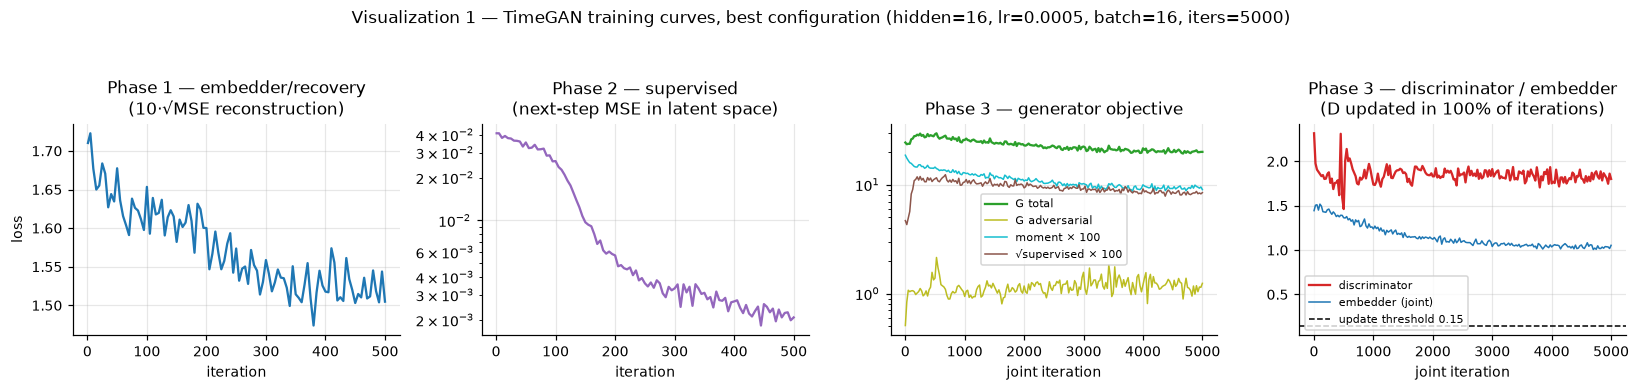

In [20]:
# ---- Visualization 1: TimeGAN training curves, best configuration ---------------------
h  = BEST_HIST
mk = "." if len(h["it_p3"]) < 60 else None     # markers only when there are few logged points
fig, ax = plt.subplots(1, 4, figsize=(15, 3.3))
ax[0].plot(h["it_p1"], h["emb"], color="tab:blue", marker=mk)
ax[0].set_title("Phase 1 — embedder/recovery\n(10·√MSE reconstruction)")
ax[0].set_xlabel("iteration"); ax[0].set_ylabel("loss")
ax[1].plot(h["it_p2"], h["sup"], color="tab:purple", marker=mk)
ax[1].set_title("Phase 2 — supervised\n(next-step MSE in latent space)")
ax[1].set_xlabel("iteration"); ax[1].set_yscale("log")
ax[2].plot(h["it_p3"], h["g"], color="tab:green", marker=mk, label="G total")
ax[2].plot(h["it_p3"], h["g_u"], color="tab:olive", lw=1, label="G adversarial")
ax[2].plot(h["it_p3"], np.array(h["g_v"]) * ETA_MOMENT, color="tab:cyan", lw=1,
           label=f"moment × {ETA_MOMENT:g}")
ax[2].plot(h["it_p3"], np.sqrt(np.array(h["g_s"])) * ETA_SUP, color="tab:brown", lw=1,
           label=f"√supervised × {ETA_SUP:g}")
ax[2].set_title("Phase 3 — generator objective"); ax[2].set_xlabel("joint iteration")
ax[2].set_yscale("log"); ax[2].legend(fontsize=7)
ax[3].plot(h["it_p3"], h["d"], color="tab:red", marker=mk, label="discriminator")
ax[3].plot(h["it_p3"], h["e"], color="tab:blue", lw=1, label="embedder (joint)")
ax[3].axhline(D_THRESHOLD, color="black", ls="--", lw=1, label=f"update threshold {D_THRESHOLD}")
ax[3].set_title(f"Phase 3 — discriminator / embedder\n"
                f"(D updated in {BEST_RES['d_update_rate']*100:.0f}% of iterations)")
ax[3].set_xlabel("joint iteration"); ax[3].legend(fontsize=7)
fig.suptitle(f"Visualization 1 — TimeGAN training curves, best configuration "
             f"(hidden={BEST_CFG['hidden_dim']}, lr={BEST_CFG['lr']:g}, "
             f"batch={BEST_CFG['batch_size']}, iters={BEST_CFG['iters']})", y=1.06)
fig.tight_layout(); savefig(fig, "viz1_training_curves"); plt.show()

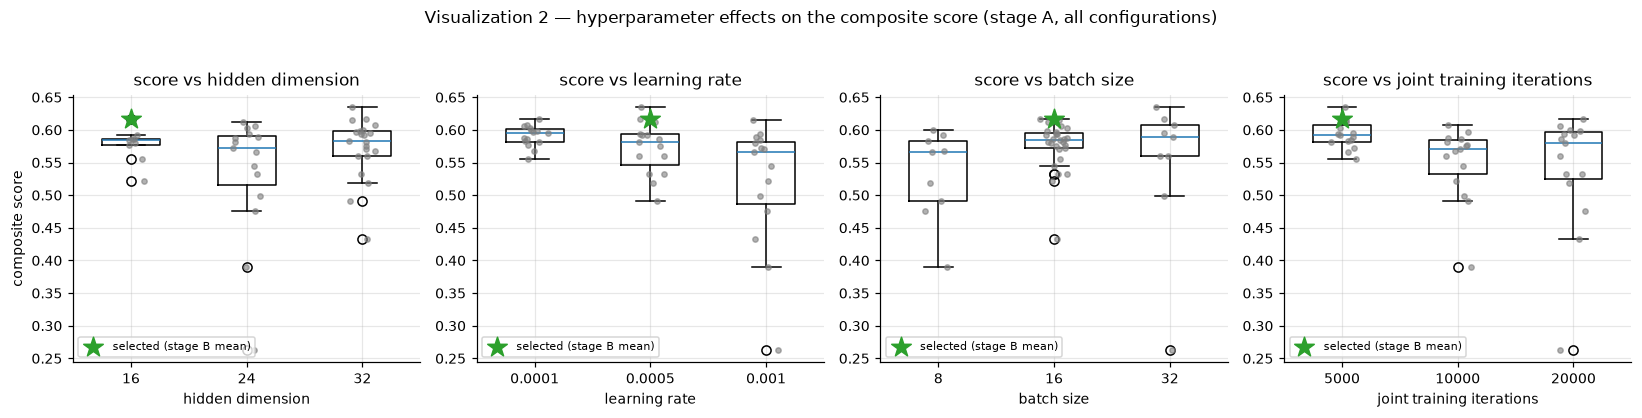

In [21]:
# ---- Visualization 2: hyperparameter vs composite score -------------------------------
params = [("hidden_dim", "hidden dimension"), ("lr", "learning rate"),
          ("batch_size", "batch size"), ("iters", "joint training iterations")]
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
for ax, (p, lbl) in zip(axes, params):
    vals = sorted(stage_a[p].unique())
    data = [stage_a.loc[stage_a[p] == v, "score"].values for v in vals]
    ax.boxplot(data, positions=range(len(vals)), widths=0.5,
               medianprops=dict(color="tab:blue"))
    for i, v in enumerate(vals):
        y = stage_a.loc[stage_a[p] == v, "score"].values
        ax.scatter(np.full(len(y), i) + np.random.uniform(-0.12, 0.12, len(y)), y,
                   s=12, color="tab:gray", alpha=0.6, zorder=3)
    sel = vals.index(BEST_CFG[p]) if BEST_CFG[p] in vals else None
    if sel is not None:
        ax.scatter([sel], [CHOSEN.score_mean], marker="*", s=180, color="tab:green",
                   zorder=4, label="selected (stage B mean)")
        ax.legend(fontsize=7, loc="lower left")
    ax.set_xticks(range(len(vals))); ax.set_xticklabels([f"{v:g}" for v in vals])
    ax.set_xlabel(lbl); ax.set_ylabel("composite score" if p == "hidden_dim" else "")
    ax.set_title(f"score vs {lbl}")
fig.suptitle("Visualization 2 — hyperparameter effects on the composite score "
             "(stage A, all configurations)", y=1.04)
fig.tight_layout(); savefig(fig, "viz2_hyperparameter_effects"); plt.show()

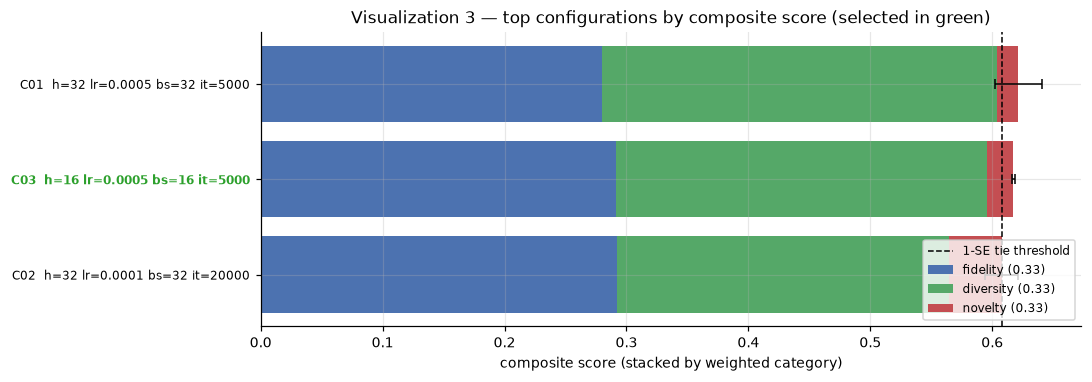

In [22]:
# ---- Visualization 3: configuration ranking -------------------------------------------
top = summary.head(min(10, len(summary))).iloc[::-1]
lbl = [f"{r.config_id}  h={int(r.hidden_dim)} lr={r.lr:g} bs={int(r.batch_size)} it={int(r.iters)}"
       for r in top.itertuples()]
fig, ax = plt.subplots(figsize=(10, 0.45 * len(top) + 2.2))
y, left = np.arange(len(top)), np.zeros(len(top))
for comp, color in zip(["fidelity", "diversity", "novelty"], ["#4C72B0", "#55A868", "#C44E52"]):
    vals = top[f"{comp}_mean"].values * CATEGORY_WEIGHTS[comp]
    ax.barh(y, vals, left=left, color=color, label=f"{comp} ({CATEGORY_WEIGHTS[comp]:.2f})")
    left += vals
ax.errorbar(top["score_mean"], y, xerr=top["score_std"].fillna(0), fmt="none",
            ecolor="black", capsize=3, lw=1)
ax.axvline(SCORE_THRESH, color="black", ls="--", lw=1,
           label="1-SE tie threshold" if ONE_SE_RULE else None)
ax.set_yticks(y); ax.set_yticklabels(lbl, fontsize=8)
ax.set_xlabel("composite score (stacked by weighted category)")
if CHOSEN.config_id in list(top.config_id):
    k = list(top.config_id).index(CHOSEN.config_id)
    ax.get_yticklabels()[k].set_color("tab:green"); ax.get_yticklabels()[k].set_fontweight("bold")
ax.set_title("Visualization 3 — top configurations by composite score (selected in green)")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout(); savefig(fig, "viz3_configuration_ranking"); plt.show()

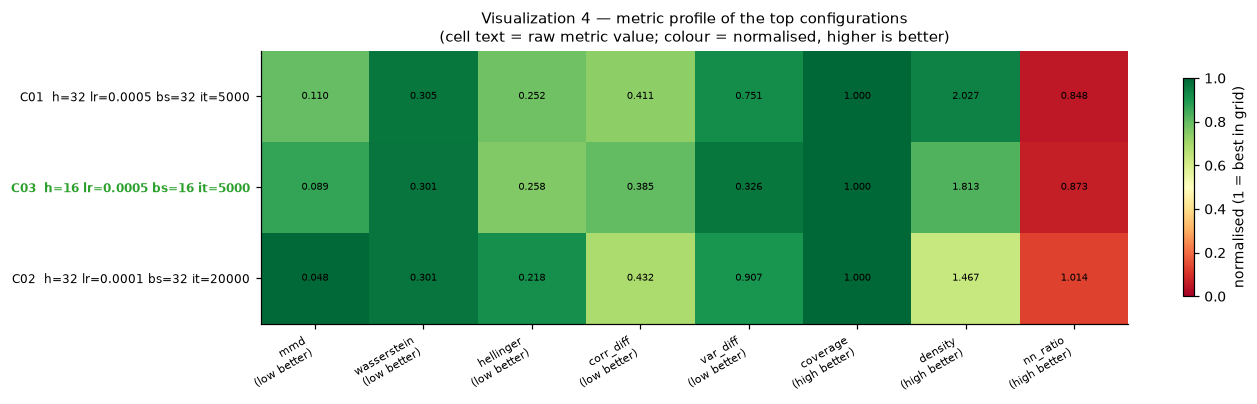

In [23]:
# ---- Visualization 4: metric comparison across the top configurations -----------------
# normalised values (1 = best in grid on that metric) so fidelity/diversity/novelty trade-offs show
mcols = list(METRIC_DIRECTION)
top_o = summary.head(min(10, len(summary)))
M = np.array([[normalize_metric(r[f"{m}_mean"], m, BOUNDS) for m in mcols]
              for _, r in top_o.iterrows()])
fig, ax = plt.subplots(figsize=(1.05 * len(mcols) + 4, 0.45 * len(top_o) + 2.4))
im = ax.imshow(M, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(mcols)))
ax.set_xticklabels([f"{m}\n({'high' if METRIC_DIRECTION[m] > 0 else 'low'} better)" for m in mcols],
                   fontsize=7, rotation=30, ha="right")
ax.set_yticks(range(len(top_o)))
ax.set_yticklabels([f"{r.config_id}  h={int(r.hidden_dim)} lr={r.lr:g} "
                    f"bs={int(r.batch_size)} it={int(r.iters)}" for _, r in top_o.iterrows()],
                   fontsize=8)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        ax.text(j, i, f"{top_o.iloc[i][f'{mcols[j]}_mean']:.3f}", ha="center", va="center",
                fontsize=6.5, color="black")
for i, cid in enumerate(top_o.config_id):
    if cid == CHOSEN.config_id:
        ax.get_yticklabels()[i].set_color("tab:green"); ax.get_yticklabels()[i].set_fontweight("bold")
fig.colorbar(im, ax=ax, shrink=0.8, label="normalised (1 = best in grid)")
ax.set_title("Visualization 4 — metric profile of the top configurations\n"
             "(cell text = raw metric value; colour = normalised, higher is better)", fontsize=10)
ax.grid(False)
fig.tight_layout(); savefig(fig, "viz4_metric_comparison"); plt.show()

representative channels: {'IMU ch0': 0, 'IMU ch1': 1, 'IMU ch2': 2, 'Radar ch373 (var rank 1)': 373, 'Radar ch46 (var rank 284)': 46, 'Radar ch668 (var rank 568)': 668}


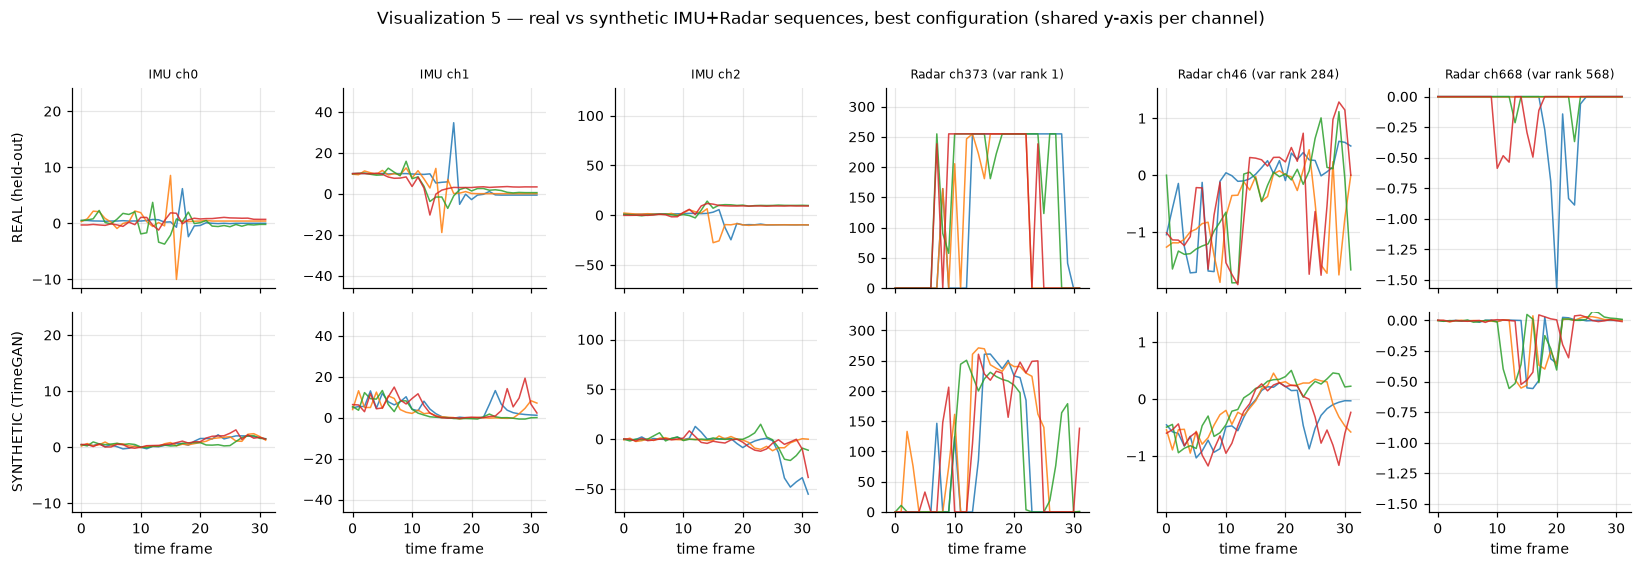

In [24]:
# ---- representative channels ----------------------------------------------------------
# 1137 features cannot be plotted at once: use the IMU accelerometer channels plus radar channels
# spread across the variance ranking (not three adjacent high-variance bins).
N_IMU = min(3, N_FEATURES)
imu_ch = list(range(N_IMU))
rad_var   = X_raw[:, :, N_IMU:].reshape(-1, N_FEATURES - N_IMU).var(axis=0)
rad_order = np.argsort(rad_var)[::-1]
picks     = [0, len(rad_order) // 4, len(rad_order) // 2]
rad_ch    = [int(N_IMU + rad_order[p]) for p in picks]
REPR_CHANNELS = imu_ch + rad_ch
REPR_LABELS   = [f"IMU ch{c}" for c in imu_ch] + \
                [f"Radar ch{c} (var rank {p+1})" for c, p in zip(rad_ch, picks)]
print("representative channels:", dict(zip(REPR_LABELS, REPR_CHANNELS)))

# ---- Visualization 5: real vs synthetic sequences -------------------------------------
rng_v = np.random.default_rng(BASE_SEED)
r_idx = rng_v.choice(len(X_VAL_RAW), size=min(4, len(X_VAL_RAW)), replace=False)
s_idx = rng_v.choice(len(BEST_SYNTH), size=4, replace=False)
fig, axes = plt.subplots(2, len(REPR_CHANNELS), figsize=(2.5 * len(REPR_CHANNELS), 5), sharex=True)
for j, (ch, name) in enumerate(zip(REPR_CHANNELS, REPR_LABELS)):
    for i in r_idx: axes[0, j].plot(X_VAL_RAW[i, :, ch], lw=1, alpha=0.85)
    for i in s_idx: axes[1, j].plot(BEST_SYNTH[i, :, ch], lw=1, alpha=0.85)
    axes[0, j].set_title(name, fontsize=8); axes[1, j].set_xlabel("time frame")
    lo = min(X_VAL_RAW[:, :, ch].min(), BEST_SYNTH[:, :, ch].min())
    hi = max(X_VAL_RAW[:, :, ch].max(), BEST_SYNTH[:, :, ch].max())
    for row in (0, 1): axes[row, j].set_ylim(lo, hi)
axes[0, 0].set_ylabel("REAL (held-out)"); axes[1, 0].set_ylabel("SYNTHETIC (TimeGAN)")
fig.suptitle("Visualization 5 — real vs synthetic IMU+Radar sequences, best configuration "
             "(shared y-axis per channel)", y=1.02)
fig.tight_layout(); savefig(fig, "viz5_real_vs_synthetic_sequences"); plt.show()

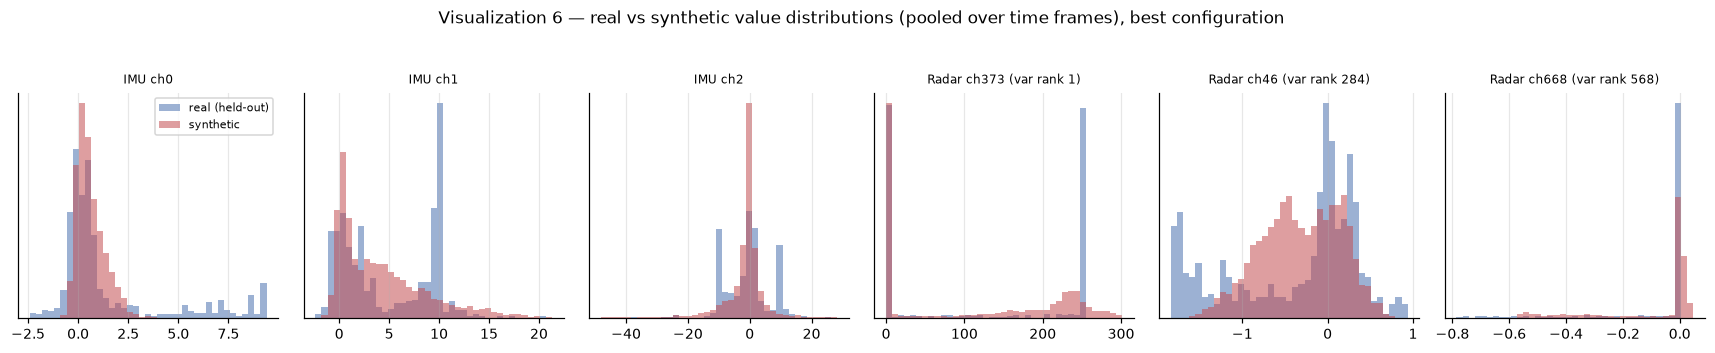

In [25]:
# ---- Visualization 6: distribution comparison ----------------------------------------
fig, axes = plt.subplots(1, len(REPR_CHANNELS), figsize=(2.6 * len(REPR_CHANNELS), 3.0))
for ax, ch, name in zip(np.atleast_1d(axes), REPR_CHANNELS, REPR_LABELS):
    r, s = X_VAL_RAW[:, :, ch].ravel(), BEST_SYNTH[:, :, ch].ravel()
    lo, hi = np.percentile(np.concatenate([r, s]), [0.5, 99.5])
    bins = np.linspace(lo, hi, 40)
    ax.hist(r, bins=bins, density=True, alpha=0.55, label="real (held-out)", color="#4C72B0")
    ax.hist(s, bins=bins, density=True, alpha=0.55, label="synthetic", color="#C44E52")
    ax.set_title(name, fontsize=8); ax.set_yticks([])
np.atleast_1d(axes)[0].legend(fontsize=7)
fig.suptitle("Visualization 6 — real vs synthetic value distributions (pooled over time frames), "
             "best configuration", y=1.05)
fig.tight_layout(); savefig(fig, "viz6_distribution_comparison"); plt.show()

# Recommended TimeGAN Configuration

The text below is generated **from the computed results**: fidelity, diversity, novelty, stability
across seeds, training behaviour, overfitting and mode-collapse diagnostics, and whether more
capacity or longer training actually bought anything. Where the evidence is unflattering it says so.

In [26]:
def pct_rank(series, value, higher_better):
    v = series.dropna().to_numpy(dtype=float)
    if len(v) < 2: return 0.5
    return float((v <= value).mean() if higher_better else (v >= value).mean())

c, L = CHOSEN, []
sd = 0.0 if pd.isna(c.score_std) else float(c.score_std)
L.append(f"## Selected configuration: **{c.config_id}** — hidden = {BEST_CFG['hidden_dim']}, "
         f"lr = {BEST_CFG['lr']:g}, batch = {BEST_CFG['batch_size']}, "
         f"joint iterations = {BEST_CFG['iters']}")
L.append(f"Composite score **{c.score_mean:.4f} ± {sd:.4f}** over {int(c.n_seeds)} seeds "
         f"(range {c.score_min:.4f}–{c.score_max:.4f}); fidelity {c.fidelity_mean:.3f}, "
         f"diversity {c.diversity_mean:.3f}, novelty {c.novelty_mean:.3f}.")

f_rank = pct_rank(summary["fidelity_mean"], c.fidelity_mean, True)
L.append(f"\n**Fidelity.** MMD {c.mmd_mean:.4f} (best in grid {summary.mmd_mean.min():.4f}), "
         f"Wasserstein {c.wasserstein_mean:.4f}, Hellinger {c.hellinger_mean:.4f}, correlation "
         f"difference {c.corr_diff_mean:.4f}, variance difference {c.var_diff_mean:.3f}. That places it "
         f"at the {f_rank*100:.0f}% mark of the repeated configurations on fidelity. "
         + ("Fidelity is a genuine strength of this configuration."
            if f_rank >= 0.6 else
            "Fidelity is mid-pack — the score is carried by diversity and novelty. With a "
            f"{len(VAL_IDX)}-sample reference the distributional metrics are noisy, so this is "
            "acceptable, but it is worth re-checking downstream."))

L.append(f"\n**Diversity.** Coverage {c.coverage_mean:.3f}, density {c.density_mean:.3f}. "
         + ("Most of the held-out real manifold is reached by the synthetic set."
            if c.coverage_mean >= 0.6 else
            "Coverage is moderate: part of the real manifold is not being generated. The later "
            "sample-size study may compensate partly by generating more sequences, but this is the "
            "main quality limit of this configuration."))

L.append(f"\n**Novelty.** NN ratio {c.nn_ratio_mean:.3f} (synthetic→real nearest-neighbour distance "
         f"divided by real→real; ≈1 means synthetic sequences sit as far from real ones as real "
         f"ones sit from each other, ≪1 means copying). Memorisation diagnostic "
         f"{c.memo_rate_mean:.3f}" +
         (" — near-duplication is not a dominant failure mode here."
          if c.memo_rate_mean <= 0.25 else
          " — a substantial share of synthetic sequences are near-copies of real ones; treat this "
          "configuration as partly a resampler and confirm with the downstream utility check."))

cv = 0.0 if c.score_mean == 0 else sd / abs(c.score_mean)
cv_med = float((summary.score_std.fillna(0) / summary.score_mean.abs()).median())
L.append(f"\n**Stability across seeds.** SD {sd:.4f} (CV {cv*100:.1f}%), min–max spread "
         f"{c.score_max - c.score_min:.4f}, versus a median CV of {cv_med*100:.1f}% across the "
         f"repeated configurations. "
         + ("This is one of the more reproducible configurations — important for an adversarial "
            "model that will be re-trained in the next pipeline stage."
            if cv <= cv_med else
            "This configuration is noisier than average across seeds; its exact rank should be "
            "treated as provisional."))

L.append(f"\n**Training behaviour.** The discriminator was updated in "
         f"{c.d_update_rate_mean*100:.0f}% of joint iterations (it is updated only when its loss "
         f"exceeds {D_THRESHOLD}). "
         + ("That is a healthy adversarial balance: the discriminator is neither idle nor dominant."
            if 0.15 <= c.d_update_rate_mean <= 0.85 else
            ("A very low rate means the discriminator stays below the threshold almost always — it "
             "is winning easily, and the generator receives a weak adversarial signal."
             if c.d_update_rate_mean < 0.15 else
             "A very high rate means the discriminator is struggling throughout; the generator may "
             "be exploiting a weak critic rather than matching the real distribution."))
         + f" Final losses (diagnostic only, never used for ranking): G {c.g_loss_mean:.3f}, "
           f"D {c.d_loss_mean:.3f}, E {c.e_loss_mean:.3f}.")

L.append(f"\n**Overfitting / memorisation.** MMD against the training split minus MMD against the "
         f"held-out split is {c.mmd_train_gap_mean:+.4f}. "
         + ("Synthetic data is no closer to the training sequences than to unseen ones, so the "
            "generator is not simply replaying what it saw."
            if c.mmd_train_gap_mean / max(abs(c.mmd_mean), 1e-9) > -0.25 else
            "Synthetic data is noticeably closer to the training sequences than to the held-out "
            "ones — the generator leans on the specific sequences it was trained on, so the "
            "downstream evaluation must keep using a held-out reference rather than the full real set."))

collapse = (c.coverage_mean < 0.4) or (c.var_diff_mean > 0.6) or (c.density_mean < 0.3)
L.append(f"\n**Mode collapse.** Coverage {c.coverage_mean:.3f}, density {c.density_mean:.3f}, "
         f"variance difference {c.var_diff_mean:.3f}. "
         + ("No collapse signature: the synthetic set spreads across the real manifold with a "
            "comparable variance."
            if not collapse else
            "These values carry a collapse signature (low coverage and/or badly mismatched "
            "variance) — the generator concentrates on a narrow region. Inspect Visualization 5 "
            "before using this configuration."))

by_h  = stage_a.groupby("hidden_dim")["score"].mean()
by_it = stage_a.groupby("iters")["score"].mean()
by_lr = stage_a.groupby("lr")["score"].agg(["mean", "std"])
L.append(f"\n**Does more capacity help?** Mean composite score by hidden dimension: "
         + ", ".join(f"{int(k)} → {v:.3f}" for k, v in by_h.items()) + ". "
         + ("Larger hidden dimensions do not buy quality here, which is consistent with 79 training "
            "sequences — the smaller model is preferred."
            if by_h.idxmax() <= min(by_h.index) else
            f"The best mean is at hidden = {int(by_h.idxmax())}, so capacity does contribute, though "
            f"the spread between settings ({by_h.max() - by_h.min():.3f}) should be weighed against "
            f"the seed noise in Table 4."))

L.append(f"\n**Does longer training help?** Mean composite score by joint iterations: "
         + ", ".join(f"{int(k)} → {v:.3f}" for k, v in by_it.items()) + ". "
         + (f"Training beyond {int(BEST_CFG['iters'])} iterations does not improve the score, so the "
            f"extra cost is not justified."
            if by_it.idxmax() <= BEST_CFG["iters"] else
            f"The best mean is at {int(by_it.idxmax())} iterations; the selected configuration uses "
            f"{BEST_CFG['iters']} because the difference falls inside the 1-SE tie band."))

L.append(f"\n**Is the learning rate stable?** Mean ± SD of the composite score by learning rate: "
         + ", ".join(f"{k:g} → {r['mean']:.3f} ± {0 if pd.isna(r['std']) else r['std']:.3f}"
                     for k, r in by_lr.iterrows()) + ". "
         + f"The selected {BEST_CFG['lr']:g} "
         + ("shows the lowest across-configuration variance, i.e. it is the least sensitive to the "
            "other settings."
            if by_lr["std"].fillna(0).idxmin() == BEST_CFG["lr"] else
            f"is not the least variable setting ({by_lr['std'].fillna(0).idxmin():g} is); if you see "
            f"unstable training in the next stage, that is the first parameter to revisit."))

if len(TIED) > 1:
    others = ", ".join(f"{r.config_id} (h={int(r.hidden_dim)}, it={int(r.iters)}, {r.score_mean:.4f})"
                       for r in TIED.iloc[1:].itertuples())
    L.append(f"\n**Marginal differences reported honestly.** {len(TIED)} configurations lie within one "
             f"standard error of the leader ({SCORE_THRESH:.4f}): {others}. Those differences are "
             f"inside seed noise, so the cheaper/simpler configuration was chosen rather than the "
             f"single highest number.")
    if CHOSEN.config_id != LEADER.config_id:
        L.append(f"Concretely: **{LEADER.config_id}** achieved the highest mean composite score "
                 f"({LEADER.score_mean:.4f}, SD {0 if pd.isna(LEADER.score_std) else LEADER.score_std:.4f}, "
                 f"hidden {int(LEADER.hidden_dim)}, {int(LEADER.iters)} iterations), but "
                 f"**{CHOSEN.config_id}** ({c.score_mean:.4f}, SD {sd:.4f}, hidden "
                 f"{BEST_CFG['hidden_dim']}, {BEST_CFG['iters']} iterations) is statistically "
                 f"indistinguishable from it while being cheaper to train. "
                 f"**{CHOSEN.config_id}** is therefore recommended. If you prefer to report the "
                 f"maximiser instead, both are defensible — state the rule you used.")
else:
    L.append(f"\n**Marginal differences.** No other configuration reaches the 1-SE threshold "
             f"({SCORE_THRESH:.4f}), so the leader wins outright rather than by a margin inside "
             f"seed noise.")

L.append(f"\n**Caveats to carry forward.** The reference set is {len(VAL_IDX)} held-out real "
         f"sequences; coverage and density are noisy at that size and the multivariate Hellinger "
         f"distance saturates. This selection is a *ranking* over configurations, not an absolute "
         f"quality certificate — the downstream sample-size study and post-evaluation remain the "
         f"real test.")

JUSTIFICATION = "\n".join(L)
display(Markdown(JUSTIFICATION))

## Selected configuration: **C03** — hidden = 16, lr = 0.0005, batch = 16, joint iterations = 5000
Composite score **0.6173 ± 0.0014** over 2 seeds (range 0.6163–0.6183); fidelity 0.874, diversity 0.913, novelty 0.065.

**Fidelity.** MMD 0.0894 (best in grid 0.0477), Wasserstein 0.3011, Hellinger 0.2580, correlation difference 0.3850, variance difference 0.326. That places it at the 67% mark of the repeated configurations on fidelity. Fidelity is a genuine strength of this configuration.

**Diversity.** Coverage 1.000, density 1.813. Most of the held-out real manifold is reached by the synthetic set.

**Novelty.** NN ratio 0.873 (synthetic→real nearest-neighbour distance divided by real→real; ≈1 means synthetic sequences sit as far from real ones as real ones sit from each other, ≪1 means copying). Memorisation diagnostic 0.343 — a substantial share of synthetic sequences are near-copies of real ones; treat this configuration as partly a resampler and confirm with the downstream utility check.

**Stability across seeds.** SD 0.0014 (CV 0.2%), min–max spread 0.0020, versus a median CV of 2.2% across the repeated configurations. This is one of the more reproducible configurations — important for an adversarial model that will be re-trained in the next pipeline stage.

**Training behaviour.** The discriminator was updated in 100% of joint iterations (it is updated only when its loss exceeds 0.15). A very high rate means the discriminator is struggling throughout; the generator may be exploiting a weak critic rather than matching the real distribution. Final losses (diagnostic only, never used for ranking): G 21.592, D 1.787, E 1.035.

**Overfitting / memorisation.** MMD against the training split minus MMD against the held-out split is +0.0255. Synthetic data is no closer to the training sequences than to unseen ones, so the generator is not simply replaying what it saw.

**Mode collapse.** Coverage 1.000, density 1.813, variance difference 0.326. No collapse signature: the synthetic set spreads across the real manifold with a comparable variance.

**Does more capacity help?** Mean composite score by hidden dimension: 16 → 0.578, 24 → 0.534, 32 → 0.573. Larger hidden dimensions do not buy quality here, which is consistent with 79 training sequences — the smaller model is preferred.

**Does longer training help?** Mean composite score by joint iterations: 5000 → 0.593, 10000 → 0.551, 20000 → 0.539. Training beyond 5000 iterations does not improve the score, so the extra cost is not justified.

**Is the learning rate stable?** Mean ± SD of the composite score by learning rate: 0.0001 → 0.591 ± 0.016, 0.0005 → 0.572 ± 0.040, 0.001 → 0.520 ± 0.096. The selected 0.0005 is not the least variable setting (0.0001 is); if you see unstable training in the next stage, that is the first parameter to revisit.

**Marginal differences reported honestly.** 2 configurations lie within one standard error of the leader (0.6077): C01 (h=32, it=5000, 0.6215). Those differences are inside seed noise, so the cheaper/simpler configuration was chosen rather than the single highest number.
Concretely: **C01** achieved the highest mean composite score (0.6215, SD 0.0195, hidden 32, 5000 iterations), but **C03** (0.6173, SD 0.0014, hidden 16, 5000 iterations) is statistically indistinguishable from it while being cheaper to train. **C03** is therefore recommended. If you prefer to report the maximiser instead, both are defensible — state the rule you used.

**Caveats to carry forward.** The reference set is 20 held-out real sequences; coverage and density are noisy at that size and the multivariate Hellinger distance saturates. This selection is a *ranking* over configurations, not an absolute quality certificate — the downstream sample-size study and post-evaluation remain the real test.

## §18. Save results

Everything is written under the timestamped run directory from §2 — no existing project file is
modified.

In [27]:
all_runs = pd.concat([stage_a, stage_b[stage_b.stage == "B"]], ignore_index=True, sort=False)
all_runs["config_id"] = all_runs["config_key"].map(CONFIG_ID)

p_results = RUN_DIR / "timegan_grid_search_results.csv"
p_top     = RUN_DIR / "timegan_top_configurations.csv"
p_stab    = RUN_DIR / "timegan_stability.csv"
p_best    = RUN_DIR / "timegan_best_config.json"
p_summary = RUN_DIR / "timegan_selection_summary.json"
p_report  = RUN_DIR / "timegan_selection_report.md"

all_runs.to_csv(p_results, index=False)
summary.to_csv(p_top, index=False)
table4.to_csv(p_stab, index=False)

model_paths = []
for name, net in [("embedder", BEST_MODEL.embedder), ("recovery", BEST_MODEL.recovery),
                  ("generator", BEST_MODEL.generator), ("supervisor", BEST_MODEL.supervisor),
                  ("discriminator", BEST_MODEL.discriminator)]:
    pk = RUN_DIR / f"timegan_best_model_{name}.keras"
    pw = RUN_DIR / f"timegan_best_model_{name}.weights.h5"
    net.save(pk); net.save_weights(pw)
    model_paths += [pk, pw]

best_payload = {
    "experiment": "TimeGAN hyperparameter grid search — IMU + Radar",
    "run_id": RUN_ID,
    "selected_at": datetime.now().isoformat(timespec="seconds"),
    "config_id": str(CHOSEN.config_id),
    "hyperparameters": BEST_CFG,
    "fixed_training_settings": {
        "emb_iters": EMB_ITERS, "sup_iters": SUP_ITERS, "num_layers": NUM_LAYERS,
        "gamma": GAMMA, "eta_supervised": ETA_SUP, "eta_moment": ETA_MOMENT,
        "g_steps_per_iter": G_STEPS_PER_ITER, "d_update_threshold": D_THRESHOLD},
    "preprocessing": {
        "signed_log": USE_SIGNED_LOG, "drop_constant": DROP_CONSTANT, "use_pca": USE_PCA,
        "pca_dims": PCA_DIMS, "effective_dim": int(PREP_DIM),
        "explained_variance_ratio": float(PREP.explained_), "minmax_range": [0, 1]},
    "data": {"path": str(data_path), "shape": list(X_raw.shape),
             "train_idx": TRAIN_IDX.tolist(), "val_idx": VAL_IDX.tolist(),
             "split_seed": SPLIT_SEED, "val_fraction": VAL_FRACTION},
    "evaluation": {"n_synth_eval": N_SYNTH_EVAL, "embed_dims": int(EVAL_CTX["k"]),
                   "prdc_k": PRDC_K, "seeds": REPEAT_SEEDS, "n_seeds_best": int(CHOSEN.n_seeds),
                   "category_weights": CATEGORY_WEIGHTS, "grid_mode": GRID_MODE_USED,
                   "n_configurations": int(len(stage_a)),
                   "n_trajectories": int(stage_a.groupby(['hidden_dim','lr','batch_size']).ngroups)},
    "metrics_mean": {m: float(CHOSEN[f"{m}_mean"]) for m in list(METRIC_DIRECTION) + DIAGNOSTIC_METRICS},
    "metrics_std": {m: (None if pd.isna(CHOSEN[f"{m}_std"]) else float(CHOSEN[f"{m}_std"]))
                    for m in list(METRIC_DIRECTION) + DIAGNOSTIC_METRICS},
    "composite_score": {"mean": float(CHOSEN.score_mean),
                        "std": (None if pd.isna(CHOSEN.score_std) else float(CHOSEN.score_std)),
                        "min": float(CHOSEN.score_min), "max": float(CHOSEN.score_max),
                        "fidelity": float(CHOSEN.fidelity_mean),
                        "diversity": float(CHOSEN.diversity_mean),
                        "novelty": float(CHOSEN.novelty_mean),
                        "one_se_threshold": SCORE_THRESH, "raw_leader": str(LEADER.config_id)},
    "next_pipeline_step": "1x-10x synthetic sample-size selection, 5 repetitions per size",
}
with open(p_best, "w") as f: json.dump(best_payload, f, indent=2)
with open(p_summary, "w") as f: json.dump(best_payload, f, indent=2)
with open(p_report, "w") as f:
    f.write(f"# TimeGAN hyperparameter selection — run {RUN_ID}\n\n{JUSTIFICATION}\n")
(RUN_DIR / "_partial_results.csv").unlink(missing_ok=True)

print("Saved:")
for p in [p_results, p_top, p_stab, p_best, p_summary, p_report] + model_paths:
    print(f"   {p.relative_to(OUTPUT_ROOT.parent)}  ({p.stat().st_size/1024:.1f} KB)")
print(f"   {FIG_DIR.relative_to(OUTPUT_ROOT.parent)}/  ({len(list(FIG_DIR.glob('*.png')))} figures)")

Saved:
   timegan_grid_search\run_20260914_232028\timegan_grid_search_results.csv  (27.1 KB)
   timegan_grid_search\run_20260914_232028\timegan_top_configurations.csv  (2.9 KB)
   timegan_grid_search\run_20260914_232028\timegan_stability.csv  (0.3 KB)
   timegan_grid_search\run_20260914_232028\timegan_best_config.json  (3.8 KB)
   timegan_grid_search\run_20260914_232028\timegan_selection_summary.json  (3.8 KB)
   timegan_grid_search\run_20260914_232028\timegan_selection_report.md  (3.9 KB)
   timegan_grid_search\run_20260914_232028\timegan_best_model_embedder.keras  (55.3 KB)
   timegan_grid_search\run_20260914_232028\timegan_best_model_embedder.weights.h5  (49.9 KB)
   timegan_grid_search\run_20260914_232028\timegan_best_model_recovery.keras  (53.3 KB)
   timegan_grid_search\run_20260914_232028\timegan_best_model_recovery.weights.h5  (47.9 KB)
   timegan_grid_search\run_20260914_232028\timegan_best_model_generator.keras  (55.3 KB)
   timegan_grid_search\run_20260914_232028\timegan_bes

# Final Recommendation

In [28]:
rec = f"""
**Selected TimeGAN configuration** (configuration {CHOSEN.config_id}, chosen from {len(stage_a)}
configurations across {stage_a.groupby(['hidden_dim','lr','batch_size']).ngroups} trajectories,
{int(CHOSEN.n_seeds)} robustness seeds on the winner):

* **Hidden dimension = {BEST_CFG['hidden_dim']}**
* **Learning rate = {BEST_CFG['lr']:g}**
* **Batch size = {BEST_CFG['batch_size']}**
* **Training iterations (joint phase) = {BEST_CFG['iters']}**

Held fixed alongside them: {EMB_ITERS} embedding iterations, {SUP_ITERS} supervised iterations,
{NUM_LAYERS} GRU layers, {G_STEPS_PER_ITER} generator+embedder steps per discriminator step with the
discriminator updated only when its loss exceeds {D_THRESHOLD}, and the existing reversible
signed-log → drop-constant → PCA({PREP_DIM}) → MinMax representation.

**Why this configuration was selected:**

* *Fidelity* — MMD {CHOSEN.mmd_mean:.4f}, Wasserstein {CHOSEN.wasserstein_mean:.4f},
  Hellinger {CHOSEN.hellinger_mean:.4f}, correlation difference {CHOSEN.corr_diff_mean:.4f},
  variance difference {CHOSEN.var_diff_mean:.3f} (category score {CHOSEN.fidelity_mean:.3f}).
* *Diversity* — coverage {CHOSEN.coverage_mean:.3f}, density {CHOSEN.density_mean:.3f}
  (category score {CHOSEN.diversity_mean:.3f}).
* *Novelty* — NN ratio {CHOSEN.nn_ratio_mean:.3f}, memorisation rate {CHOSEN.memo_rate_mean:.3f}
  (category score {CHOSEN.novelty_mean:.3f}).
* *Stability* — composite {CHOSEN.score_mean:.4f} ± {0.0 if pd.isna(CHOSEN.score_std) else CHOSEN.score_std:.4f}
  over {int(CHOSEN.n_seeds)} seeds (range {CHOSEN.score_min:.4f}–{CHOSEN.score_max:.4f}),
  discriminator updated in {CHOSEN.d_update_rate_mean*100:.0f}% of joint iterations.

Selection used the composite score (equal thirds fidelity / diversity / novelty) with a 1-SE
simplicity rule; training losses were never part of the ranking. Full reasoning in §17.

**Next pipeline step:** use this selected TimeGAN configuration in the existing
**1×–10× synthetic sample-size selection**, with **5 repetitions per sample size → mean metrics →
sample-size selection → final generation → post-evaluation**. Load it with:

```python
import json
best = json.load(open(r"{p_best}"))["hyperparameters"]
```

*This notebook selected hyperparameters only. It did not choose a synthetic sample size, did not
generate the final production dataset, and did not modify any existing project file.*
"""
display(Markdown(rec))


**Selected TimeGAN configuration** (configuration C03, chosen from 45
configurations across 15 trajectories,
2 robustness seeds on the winner):

* **Hidden dimension = 16**
* **Learning rate = 0.0005**
* **Batch size = 16**
* **Training iterations (joint phase) = 5000**

Held fixed alongside them: 500 embedding iterations, 500 supervised iterations,
3 GRU layers, 2 generator+embedder steps per discriminator step with the
discriminator updated only when its loss exceeds 0.15, and the existing reversible
signed-log → drop-constant → PCA(32) → MinMax representation.

**Why this configuration was selected:**

* *Fidelity* — MMD 0.0894, Wasserstein 0.3011,
  Hellinger 0.2580, correlation difference 0.3850,
  variance difference 0.326 (category score 0.874).
* *Diversity* — coverage 1.000, density 1.813
  (category score 0.913).
* *Novelty* — NN ratio 0.873, memorisation rate 0.343
  (category score 0.065).
* *Stability* — composite 0.6173 ± 0.0014
  over 2 seeds (range 0.6163–0.6183),
  discriminator updated in 100% of joint iterations.

Selection used the composite score (equal thirds fidelity / diversity / novelty) with a 1-SE
simplicity rule; training losses were never part of the ranking. Full reasoning in §17.

**Next pipeline step:** use this selected TimeGAN configuration in the existing
**1×–10× synthetic sample-size selection**, with **5 repetitions per sample size → mean metrics →
sample-size selection → final generation → post-evaluation**. Load it with:

```python
import json
best = json.load(open(r"c:\Users\mabideen\Downloads\Data_Augmentation\DL_Grid_Search\timegan_grid_search\run_20260914_232028\timegan_best_config.json"))["hyperparameters"]
```

*This notebook selected hyperparameters only. It did not choose a synthetic sample size, did not
generate the final production dataset, and did not modify any existing project file.*
